# Week 5 Extension — ARD Matérn 3/2 Robustness Experiment

This notebook asks one deliberately narrow question: does allowing a separate
Matérn 3/2 lengthscale for each standardized process variable improve the
first-observed-Conduction regression relative to the already evaluated
isotropic Matérn 3/2 baseline?

The experiment preserves the fixed Week 5 scientific definitions:

- one observation is one `name` simulation;
- `X = [P, VX, LS, ST]`;
- `y` is the minimum raw `timestep` with `label_final == "Conduction"`;
- the target is a simulation timestep number, not physical time;
- 91 no-Bug simulations and 238 broad simulations are analysed separately;
- the three never-Conduction simulations remain excluded.

## 1. Scientific scope and protocol

Only two kernels are compared: the prior isotropic Matérn 3/2 and the new
ARD Matérn 3/2. The latter learns four standardized-space lengthscales, one
for each input. ARD lengthscales are descriptive smoothness diagnostics;
they are **not** causal importance scores.

The exact Phase 2 preprocessing and optimizer protocol is retained:
fold-local `StandardScaler`, `normalize_y=True`, fixed `alpha=1e-6`
numerical jitter, no `WhiteKernel`, L-BFGS-B, deterministic seed, and one
additional optimizer restart. `alpha` is stabilization rather than a claim
of Gaussian simulator noise. Screenshot-Bug ambiguity is not represented by
a learned noise term or interval likelihood.

In [1]:
from __future__ import annotations

import hashlib
import json
import math
import platform
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import LeaveOneOut
from sklearn.preprocessing import StandardScaler


def find_repository_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / ".git").exists() and (candidate / "requirements.txt").exists():
            return candidate
    raise RuntimeError("Could not locate the repository root.")


ROOT = find_repository_root()
AUDIT_PATH = ROOT / "outputs/week5_01_first_conduction_data_audit/simulation_level_audit.csv"
RAW_CSV_PATH = ROOT / "data/raw/sph_dataset/final-labels_all.csv"
PHASE2_ROOT = ROOT / "outputs/week5_02_first_conduction_gp_kernel_comparison"
OUTPUT_ROOT = ROOT / "outputs/week5_05_ard_matern32_extension"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

INPUT_COLUMNS = ["P", "VX", "LS", "ST"]
TARGET_COLUMN = "first_observed_conduction_timestep"
GROUP_COLUMN = "name"
EXPECTED_CLEAN = 91
EXPECTED_BROAD = 238
EXPECTED_NEVER_CONDUCTION = 3
CSV_SHA256_EXPECTED = "964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154"

RANDOM_SEED = 20260721
BOOTSTRAP_SEED = 20260723
BOOTSTRAP_RESAMPLES = 10_000
ALPHA_JITTER = 1e-6
OPTIMIZER = "fmin_l_bfgs_b"
EXTRA_OPTIMIZER_RESTARTS = 1
NORMALIZE_Y = True
CONSTANT_INITIAL_VALUE = 1.0
CONSTANT_BOUNDS = (1e-3, 1e3)
PRIMARY_LENGTH_BOUNDS = (1e-2, 1e2)
WIDENED_LENGTH_BOUNDS = (1e-2, 1e3)
ARD_INITIAL_LENGTHS = np.ones(4)
INTERVAL_Z = 1.959963984540054
BOUND_RTOL = 1e-5

ISO_KEY = "matern_3_2"
ARD_KEY = "ard_matern_3_2"
KERNEL_LABELS = {
    ISO_KEY: "Isotropic Matérn 3/2",
    ARD_KEY: "ARD Matérn 3/2",
}
COLORS = {ISO_KEY: "#0F766E", ARD_KEY: "#7C3AED"}

pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 30)
pd.set_option("display.max_colwidth", 120)
plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 180,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.22,
        "font.size": 9.5,
    }
)

configuration = pd.DataFrame(
    [
        {
            "inputs": str(INPUT_COLUMNS),
            "target": TARGET_COLUMN,
            "group": GROUP_COLUMN,
            "random_seed": RANDOM_SEED,
            "alpha_jitter": ALPHA_JITTER,
            "optimizer": OPTIMIZER,
            "extra_optimizer_restarts": EXTRA_OPTIMIZER_RESTARTS,
            "normalize_y": NORMALIZE_Y,
            "constant_initial_value": CONSTANT_INITIAL_VALUE,
            "constant_bounds": str(CONSTANT_BOUNDS),
            "ard_initial_lengthscales": str(ARD_INITIAL_LENGTHS.tolist()),
            "primary_lengthscale_bounds": str(PRIMARY_LENGTH_BOUNDS),
            "white_kernel": False,
            "bootstrap_seed": BOOTSTRAP_SEED,
            "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
            "python": platform.python_version(),
            "sklearn": sklearn.__version__,
        }
    ]
)
display(configuration)

,inputs,target,group,random_seed,alpha_jitter,optimizer,extra_optimizer_restarts,normalize_y,constant_initial_value,constant_bounds,ard_initial_lengthscales,primary_lengthscale_bounds,white_kernel,bootstrap_seed,bootstrap_resamples,python,sklearn
0,"['P', 'VX', 'LS', 'ST']",first_observed_conduction_timestep,name,20260721,0.000001,fmin_l_bfgs_b,1,True,1.0,"(0.001, 1000.0)","[1.0, 1.0, 1.0, 1.0]","(0.01, 100.0)",False,20260723,10000,3.12.13,1.9.0


**How to read this setup.** All four inputs are standardized because their
physical scales differ greatly. Bounds from 0.01 to 100 cover very local to
nearly flat response behaviour in standardized coordinates. Identical
optimization effort is used in every new LOO fit. This controls the
comparison, but it cannot guarantee a global hyperparameter optimum.

## 2. Reconstruct the fixed datasets and verify the reused isotropic baseline

In [2]:
audit = pd.read_csv(AUDIT_PATH)
required_columns = {
    GROUP_COLUMN,
    "hash",
    *INPUT_COLUMNS,
    TARGET_COLUMN,
    "reaches_conduction",
    "screenshot_bug_any",
    "screenshot_bug_before_first_conduction",
}
missing = sorted(required_columns.difference(audit.columns))
if missing:
    raise KeyError(f"Missing Phase 1 audit columns: {missing}")
if audit[GROUP_COLUMN].duplicated().any():
    raise RuntimeError("Simulation-level audit has duplicate name groups.")

broad_data = audit.loc[audit["reaches_conduction"]].copy().reset_index(drop=True)
clean_data = broad_data.loc[~broad_data["screenshot_bug_any"]].copy().reset_index(drop=True)
never_conduction = audit.loc[~audit["reaches_conduction"]].copy().reset_index(drop=True)

if (len(clean_data), len(broad_data), len(never_conduction)) != (
    EXPECTED_CLEAN,
    EXPECTED_BROAD,
    EXPECTED_NEVER_CONDUCTION,
):
    raise RuntimeError(
        "Unexpected sample counts: "
        f"clean={len(clean_data)}, broad={len(broad_data)}, "
        f"never={len(never_conduction)}"
    )
if clean_data["screenshot_bug_any"].any():
    raise RuntimeError("The operational no-Bug dataset contains Screenshot Bug.")
if broad_data[TARGET_COLUMN].isna().any():
    raise RuntimeError("Broad dataset contains an undefined target.")

raw_sha256_before = hashlib.sha256(RAW_CSV_PATH.read_bytes()).hexdigest()
if raw_sha256_before != CSV_SHA256_EXPECTED:
    raise RuntimeError(f"Raw CSV SHA-256 changed: {raw_sha256_before}")
raw_targets = pd.read_csv(
    RAW_CSV_PATH, usecols=[GROUP_COLUMN, "timestep", "label_final"]
)
raw_first = (
    raw_targets.loc[raw_targets["label_final"].eq("Conduction")]
    .groupby(GROUP_COLUMN, sort=False)["timestep"]
    .min()
    .rename("raw_recomputed_target")
)
target_reconciliation = broad_data[[GROUP_COLUMN, TARGET_COLUMN]].merge(
    raw_first,
    left_on=GROUP_COLUMN,
    right_index=True,
    how="left",
    validate="one_to_one",
)
target_reconciliation["difference"] = (
    target_reconciliation[TARGET_COLUMN]
    - target_reconciliation["raw_recomputed_target"]
)
target_mismatches = int((~target_reconciliation["difference"].eq(0)).sum())
if not target_reconciliation["difference"].eq(0).all():
    raise RuntimeError("Audit target differs from raw first observed Conduction timestep.")
del raw_targets


def load_phase2_isotropic(dataset: str, frame: pd.DataFrame) -> pd.DataFrame:
    path = PHASE2_ROOT / dataset / f"{dataset}_loo_predictions.csv"
    saved = pd.read_csv(path)
    saved = saved.loc[saved["kernel_key"].eq(ISO_KEY)].copy().reset_index(drop=True)
    if len(saved) != len(frame):
        raise RuntimeError(f"{dataset}: wrong reused isotropic row count.")
    if saved[GROUP_COLUMN].duplicated().any():
        raise RuntimeError(f"{dataset}: duplicate reused isotropic names.")
    if saved[GROUP_COLUMN].tolist() != frame[GROUP_COLUMN].tolist():
        raise RuntimeError(f"{dataset}: reused fold order or membership changed.")
    if not np.array_equal(
        saved["observed_target"].to_numpy(float),
        frame[TARGET_COLUMN].to_numpy(float),
    ):
        raise RuntimeError(f"{dataset}: reused target values changed.")

    expected_settings = {
        "alpha_jitter": ALPHA_JITTER,
        "optimizer": OPTIMIZER,
        "extra_optimizer_restarts": EXTRA_OPTIMIZER_RESTARTS,
        "random_seed": RANDOM_SEED,
    }
    for column, expected in expected_settings.items():
        if not saved[column].eq(expected).all():
            raise RuntimeError(f"{dataset}: incompatible reused setting {column}.")
    if saved["fit_failed"].astype(bool).any():
        raise RuntimeError(f"{dataset}: prior isotropic fit failure found.")
    if saved["heldout_in_scaler_fit"].astype(bool).any():
        raise RuntimeError(f"{dataset}: prior scaler leakage flag found.")
    if not saved["scaler_fit_rows"].eq(len(frame) - 1).all():
        raise RuntimeError(f"{dataset}: prior scaler training count changed.")

    # Independently recompute every fold's StandardScaler moments.
    X = frame[INPUT_COLUMNS].to_numpy(float)
    for fold_index in range(len(frame)):
        train_mask = np.arange(len(frame)) != fold_index
        scaler = StandardScaler().fit(X[train_mask])
        row = saved.iloc[fold_index]
        for input_index, input_name in enumerate(INPUT_COLUMNS):
            if not np.isclose(
                row[f"scaler_training_mean_{input_name}"],
                scaler.mean_[input_index],
                rtol=0,
                atol=1e-12,
            ):
                raise RuntimeError(f"{dataset}: prior scaler mean mismatch.")
            if not np.isclose(
                row[f"scaler_training_scale_{input_name}"],
                scaler.scale_[input_index],
                rtol=0,
                atol=1e-12,
            ):
                raise RuntimeError(f"{dataset}: prior scaler scale mismatch.")

    saved["kernel_label"] = KERNEL_LABELS[ISO_KEY]
    saved["result_origin"] = "reused_exact_phase2_result"
    return saved


clean_isotropic = load_phase2_isotropic("clean", clean_data)
broad_isotropic = load_phase2_isotropic("broad", broad_data)

dataset_check = pd.DataFrame(
    [
        {
            "dataset": "clean",
            "simulations": len(clean_data),
            "Screenshot_Bug_simulations": int(clean_data["screenshot_bug_any"].sum()),
            "reused_isotropic_rows": len(clean_isotropic),
            "target_min": clean_data[TARGET_COLUMN].min(),
            "target_median": clean_data[TARGET_COLUMN].median(),
            "target_max": clean_data[TARGET_COLUMN].max(),
        },
        {
            "dataset": "broad",
            "simulations": len(broad_data),
            "Screenshot_Bug_simulations": int(broad_data["screenshot_bug_any"].sum()),
            "reused_isotropic_rows": len(broad_isotropic),
            "target_min": broad_data[TARGET_COLUMN].min(),
            "target_median": broad_data[TARGET_COLUMN].median(),
            "target_max": broad_data[TARGET_COLUMN].max(),
        },
    ]
)
display(dataset_check)

,dataset,simulations,Screenshot_Bug_simulations,reused_isotropic_rows,target_min,target_median,target_max
0,clean,91,0,91,4840.0,13933.0,42436.0
1,broad,238,147,238,4840.0,29019.0,95798.0


**Interpretation.** The expected 91/238 split is reconstructed directly from
the Phase 1 simulation-level audit. Every target is reconciled to the raw
minimum Conduction timestep. The prior isotropic Matérn 3/2 results are
reused only after checking identical simulation membership, target values,
fold ordering, jitter, optimizer, restart count, seed, and fold-local
scaler statistics. This avoids repeating 329 scientifically identical fits.

## 3. ARD Matérn 3/2 implementation

In [3]:
def make_ard_kernel(
    length_bounds: tuple[float, float] = PRIMARY_LENGTH_BOUNDS,
    initial_constant: float = CONSTANT_INITIAL_VALUE,
    initial_lengths: np.ndarray | list[float] = ARD_INITIAL_LENGTHS,
):
    return ConstantKernel(
        constant_value=initial_constant,
        constant_value_bounds=CONSTANT_BOUNDS,
    ) * Matern(
        length_scale=np.asarray(initial_lengths, dtype=float),
        length_scale_bounds=length_bounds,
        nu=1.5,
    )


def make_ard_gpr(
    *,
    length_bounds: tuple[float, float] = PRIMARY_LENGTH_BOUNDS,
    initial_constant: float = CONSTANT_INITIAL_VALUE,
    initial_lengths: np.ndarray | list[float] = ARD_INITIAL_LENGTHS,
    restarts: int = EXTRA_OPTIMIZER_RESTARTS,
) -> GaussianProcessRegressor:
    return GaussianProcessRegressor(
        kernel=make_ard_kernel(length_bounds, initial_constant, initial_lengths),
        alpha=ALPHA_JITTER,
        optimizer=OPTIMIZER,
        n_restarts_optimizer=restarts,
        normalize_y=NORMALIZE_Y,
        random_state=RANDOM_SEED,
    )


def is_at_bound(value: float, bound: float) -> bool:
    return bool(np.isclose(value, bound, rtol=BOUND_RTOL, atol=1e-12))


def warning_fields(caught: list) -> tuple[int, str, str]:
    if not caught:
        return 0, "", ""
    categories = sorted({item.category.__name__ for item in caught})
    unique_messages = []
    for item in caught:
        message = f"{item.category.__name__}: {item.message}"
        if message not in unique_messages:
            unique_messages.append(message)
    return len(caught), "; ".join(categories), " || ".join(unique_messages)


def extract_ard_parameters(kernel) -> dict:
    lengths = np.atleast_1d(kernel.k2.length_scale).astype(float)
    if lengths.size != len(INPUT_COLUMNS):
        raise RuntimeError(f"Expected four ARD lengthscales, found {lengths}.")
    result = {
        "signal_variance": float(kernel.k1.constant_value),
    }
    for input_name, value in zip(INPUT_COLUMNS, lengths):
        result[f"ard_lengthscale_{input_name}"] = float(value)
        result[f"{input_name}_at_lower_bound"] = is_at_bound(
            float(value), PRIMARY_LENGTH_BOUNDS[0]
        )
        result[f"{input_name}_at_upper_bound"] = is_at_bound(
            float(value), PRIMARY_LENGTH_BOUNDS[1]
        )
    return result


def run_ard_leave_one_out(dataset: str, frame: pd.DataFrame) -> pd.DataFrame:
    X = frame[INPUT_COLUMNS].to_numpy(float)
    y = frame[TARGET_COLUMN].to_numpy(float)
    rows = []
    started_dataset = time.perf_counter()
    for fold_index, (train_index, test_index) in enumerate(LeaveOneOut().split(X)):
        if len(test_index) != 1 or np.intersect1d(train_index, test_index).size:
            raise RuntimeError("Invalid experiment-level LOO split.")
        heldout_index = int(test_index[0])
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X[train_index])
        X_test = scaler.transform(X[test_index])
        if int(scaler.n_samples_seen_) != len(train_index):
            raise RuntimeError("Fold-local scaler row count mismatch.")

        model = make_ard_gpr()
        fit_failed = False
        failure_message = ""
        fallback_used = False
        fold_started = time.perf_counter()
        with warnings.catch_warnings(record=True) as caught:
            warnings.simplefilter("always")
            try:
                model.fit(X_train, y[train_index])
            except Exception as exc:
                fit_failed = True
                failure_message = f"{type(exc).__name__}: {exc}"
                # Preserve a traceable row if L-BFGS-B fails; this is not silent.
                fallback_used = True
                model = GaussianProcessRegressor(
                    kernel=make_ard_kernel(),
                    alpha=ALPHA_JITTER,
                    optimizer=None,
                    normalize_y=NORMALIZE_Y,
                    random_state=RANDOM_SEED,
                )
                model.fit(X_train, y[train_index])
        fit_runtime = time.perf_counter() - fold_started
        prediction_started = time.perf_counter()
        predicted_mean, predicted_std = model.predict(X_test, return_std=True)
        prediction_runtime = time.perf_counter() - prediction_started
        fold_runtime = time.perf_counter() - fold_started
        mean_value = float(predicted_mean[0])
        std_value = float(predicted_std[0])
        if not np.isfinite(std_value) or std_value <= 0:
            raise RuntimeError(f"{dataset} fold {fold_index}: invalid predictive std.")
        observed = float(y[heldout_index])
        residual = observed - mean_value
        variance = std_value**2
        nlpd = 0.5 * math.log(2 * math.pi * variance) + 0.5 * residual**2 / variance
        lower = mean_value - INTERVAL_Z * std_value
        upper = mean_value + INTERVAL_Z * std_value
        warning_count, warning_categories, warning_messages = warning_fields(caught)
        parameters = extract_ard_parameters(model.kernel_)

        row = {
            "dataset": dataset,
            "fold_index": fold_index,
            "kernel_key": ARD_KEY,
            "kernel_label": KERNEL_LABELS[ARD_KEY],
            GROUP_COLUMN: frame.iloc[heldout_index][GROUP_COLUMN],
            "hash": frame.iloc[heldout_index]["hash"],
            **{
                input_name: float(frame.iloc[heldout_index][input_name])
                for input_name in INPUT_COLUMNS
            },
            "screenshot_bug_any": bool(
                frame.iloc[heldout_index]["screenshot_bug_any"]
            ),
            "screenshot_bug_before_first_conduction": bool(
                frame.iloc[heldout_index][
                    "screenshot_bug_before_first_conduction"
                ]
            ),
            "observed_target": observed,
            "predicted_mean": mean_value,
            "predicted_std": std_value,
            "residual_observed_minus_predicted": residual,
            "absolute_error": abs(residual),
            "squared_error": residual**2,
            "negative_log_predictive_density": nlpd,
            "lower_95": lower,
            "upper_95": upper,
            "covered_95": bool(lower <= observed <= upper),
            "interval_width_95": upper - lower,
            "training_simulations": len(train_index),
            "scaler_fit_rows": int(scaler.n_samples_seen_),
            "heldout_in_scaler_fit": False,
            "alpha_jitter": ALPHA_JITTER,
            "optimizer": OPTIMIZER,
            "extra_optimizer_restarts": EXTRA_OPTIMIZER_RESTARTS,
            "random_seed": RANDOM_SEED,
            "fit_runtime_seconds": fit_runtime,
            "predict_runtime_seconds": prediction_runtime,
            "fold_runtime_seconds": fold_runtime,
            "optimization_warning_count": warning_count,
            "optimization_warning_categories": warning_categories,
            "optimization_warning_messages": warning_messages,
            "fit_failed": fit_failed,
            "failure_message": failure_message,
            "fallback_used": fallback_used,
            "optimized_kernel_expression": str(model.kernel_),
            "log_marginal_likelihood_train_fold": float(
                model.log_marginal_likelihood_value_
            ),
            **parameters,
        }
        for input_name, mean_value_scaler, scale_value in zip(
            INPUT_COLUMNS, scaler.mean_, scaler.scale_
        ):
            row[f"scaler_training_mean_{input_name}"] = float(mean_value_scaler)
            row[f"scaler_training_scale_{input_name}"] = float(scale_value)
        rows.append(row)
        if (fold_index + 1) % 20 == 0 or fold_index + 1 == len(frame):
            elapsed = time.perf_counter() - started_dataset
            print(
                f"{dataset}: {fold_index + 1}/{len(frame)} ARD LOO fits "
                f"complete ({elapsed:.1f} s)"
            )
    result = pd.DataFrame(rows)
    if len(result) != len(frame):
        raise RuntimeError(f"{dataset}: expected {len(frame)} ARD predictions.")
    return result


kernel_specification = pd.DataFrame(
    [
        {
            "kernel_key": ISO_KEY,
            "kernel_expression": "ConstantKernel × Matérn(nu=1.5, shared lengthscale)",
            "lengthscale_initial": "1",
            "lengthscale_bounds": str(PRIMARY_LENGTH_BOUNDS),
            "result_origin": "verified exact reuse from Phase 2",
        },
        {
            "kernel_key": ARD_KEY,
            "kernel_expression": "ConstantKernel × Matérn(nu=1.5, [l_P, l_VX, l_LS, l_ST])",
            "lengthscale_initial": str(ARD_INITIAL_LENGTHS.tolist()),
            "lengthscale_bounds": str(PRIMARY_LENGTH_BOUNDS),
            "result_origin": "new LOO fits",
        },
    ]
)
display(kernel_specification)

,kernel_key,kernel_expression,lengthscale_initial,lengthscale_bounds,result_origin
0,matern_3_2,"ConstantKernel × Matérn(nu=1.5, shared lengthscale)",1,"(0.01, 100.0)",verified exact reuse from Phase 2
1,ard_matern_3_2,"ConstantKernel × Matérn(nu=1.5, [l_P, l_VX, l_LS, l_ST])","[1.0, 1.0, 1.0, 1.0]","(0.01, 100.0)",new LOO fits


**What is being tested.** The covariance family and differentiability
assumption remain Matérn 3/2. Only the geometry changes: isotropic uses one
lengthscale, while ARD uses four. A shorter fitted lengthscale means the
model can vary more rapidly along that standardized coordinate. It does not
establish a causal effect of that process variable.

## 4. New experiment-level LOO fits

In [4]:
clean_ard = run_ard_leave_one_out("clean", clean_data)
clean_ard.to_csv(
    OUTPUT_ROOT / "clean_ard_matern32_loo_predictions.csv", index=False
)
display(
    clean_ard[
        [
            GROUP_COLUMN,
            "observed_target",
            "predicted_mean",
            "predicted_std",
            "absolute_error",
            "optimized_kernel_expression",
        ]
    ].head()
)

clean: 20/91 ARD LOO fits complete (2.8 s)


clean: 40/91 ARD LOO fits complete (5.5 s)


clean: 60/91 ARD LOO fits complete (8.4 s)


clean: 80/91 ARD LOO fits complete (10.9 s)


clean: 91/91 ARD LOO fits complete (12.4 s)


,name,observed_target,predicted_mean,predicted_std,absolute_error,optimized_kernel_expression
0,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-3p56864695376...,11779.0,17417.782354,1005.429868,5638.782354,"1.07**2 * Matern(length_scale=[1.79, 1.09, 3.47, 100], nu=1.5)"
1,P-109p759946449_VX-0p241926176876_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-7p7287335986...,28904.0,39388.796961,1134.402948,10484.796961,"1.08**2 * Matern(length_scale=[1.12, 0.956, 22.1, 13.1], nu=1.5)"
2,P-122p148440758_VX-0p768953415756_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-2p4315945976...,9630.0,11919.032201,1211.675739,2289.032201,"1.06**2 * Matern(length_scale=[1.8, 0.939, 100, 3.45], nu=1.5)"
3,P-126p228008246_VX-0p201684842681_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-9p2708155296...,33658.0,32365.136516,1265.059295,1292.863484,"1.05**2 * Matern(length_scale=[1.8, 0.898, 100, 3.28], nu=1.5)"
4,P-133p003569327_VX-0p736244453131_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-2p5396224904...,13551.0,10257.125347,1505.188812,3293.874653,"1.07**2 * Matern(length_scale=[1.8, 0.964, 100, 3.47], nu=1.5)"


**Clean-data interpretation.** Each displayed row is a prediction for one
simulation made without using that simulation for scaling or GP fitting.
The uncertainty is model-based latent-function uncertainty under the
fixed-jitter GP. Aggregate comparison follows after the broad run, so no
conclusion should be drawn from the first few rows.

In [5]:
broad_ard = run_ard_leave_one_out("broad", broad_data)
broad_ard.to_csv(
    OUTPUT_ROOT / "broad_ard_matern32_loo_predictions.csv", index=False
)
display(
    broad_ard[
        [
            GROUP_COLUMN,
            "observed_target",
            "predicted_mean",
            "predicted_std",
            "absolute_error",
            "optimized_kernel_expression",
        ]
    ].head()
)

broad: 20/238 ARD LOO fits complete (14.8 s)


broad: 40/238 ARD LOO fits complete (29.1 s)


broad: 60/238 ARD LOO fits complete (46.3 s)


broad: 80/238 ARD LOO fits complete (61.2 s)


broad: 100/238 ARD LOO fits complete (76.4 s)


...

broad: 180/238 ARD LOO fits complete (139.3 s)


broad: 200/238 ARD LOO fits complete (155.8 s)


broad: 220/238 ARD LOO fits complete (171.4 s)


broad: 238/238 ARD LOO fits complete (184.6 s)


,name,observed_target,predicted_mean,predicted_std,absolute_error,optimized_kernel_expression
0,P-101p127472137_VX-0p52394730996_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-3p56864695376...,11779.0,15772.054176,3562.022549,3993.054176,"1.07**2 * Matern(length_scale=[1.42, 0.963, 0.895, 0.229], nu=1.5)"
1,P-104p101541641_VX-0p916529700054_LS-8p82882842693e-05_ST-394p968412652_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012_TE-0p00...,71553.0,16186.767702,16124.061113,55366.232298,"1.05**2 * Matern(length_scale=[1.57, 0.895, 0.981, 0.209], nu=1.5)"
2,P-105p276295276_VX-0p639039009111_LS-7p6636834293e-05_ST-367p44858305_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012_TE-0p0012...,29945.0,41845.965768,17609.217493,11900.965768,"1.07**2 * Matern(length_scale=[1.41, 0.952, 0.906, 0.229], nu=1.5)"
3,P-107p176159755_VX-0p320752066655_LS-8p75302281584e-05_ST-393p859643937_M-TI64_XI-0p0002_XF-0p0014_XL-0p0012_TE-0p00...,53796.0,25700.430300,15946.196338,28095.569700,"1.07**2 * Matern(length_scale=[1.4, 0.961, 0.918, 0.239], nu=1.5)"
4,P-109p759946449_VX-0p241926176876_LS-4p5e-05_ST-300_M-TI64_XI--0p0002_XF-0p0012_XL-0p0014_TE-0p00125_DT-7p7287335986...,28904.0,28322.017103,5787.277732,581.982897,"1.06**2 * Matern(length_scale=[1.4, 0.939, 0.897, 0.23], nu=1.5)"


**Broad-data interpretation.** These predictions use all other targeted
simulations, including simulations with Screenshot Bug labels. The held-out
target is still the first actually observed Conduction timestep. Better
broad metrics would show predictive usefulness under that operational
target definition; they would not prove that bug-affected labels are exact
physical transition times.

## 5. LOO metrics, paired errors, and bootstrap uncertainty

In [6]:
def summarize_predictions(predictions: pd.DataFrame) -> dict:
    observed = predictions["observed_target"].to_numpy(float)
    predicted = predictions["predicted_mean"].to_numpy(float)
    rmse = math.sqrt(mean_squared_error(observed, predicted))
    target_std = float(np.std(observed, ddof=1))
    return {
        "dataset": str(predictions["dataset"].iloc[0]),
        "kernel_key": str(predictions["kernel_key"].iloc[0]),
        "kernel_label": str(predictions["kernel_label"].iloc[0]),
        "simulations": len(predictions),
        "MAE": float(mean_absolute_error(observed, predicted)),
        "median_absolute_error": float(predictions["absolute_error"].median()),
        "RMSE": float(rmse),
        "R2": float(r2_score(observed, predicted)),
        "target_sample_std": target_std,
        "normalized_RMSE": float(rmse / target_std),
        "mean_negative_log_predictive_density": float(
            predictions["negative_log_predictive_density"].mean()
        ),
        "empirical_95_interval_coverage": float(
            predictions["covered_95"].mean()
        ),
        "coverage_error_from_0_95": float(
            abs(predictions["covered_95"].mean() - 0.95)
        ),
        "mean_95_interval_width": float(
            predictions["interval_width_95"].mean()
        ),
        "total_runtime_seconds": float(
            predictions["fold_runtime_seconds"].sum()
        ),
        "median_runtime_per_fold_seconds": float(
            predictions["fold_runtime_seconds"].median()
        ),
        "optimization_warning_count": int(
            predictions["optimization_warning_count"].sum()
        ),
        "folds_with_optimization_warning": int(
            predictions["optimization_warning_count"].gt(0).sum()
        ),
        "optimization_failures": int(predictions["fit_failed"].sum()),
        "fallback_fits": int(
            predictions.get("fallback_used", pd.Series(False)).sum()
        ),
    }


metric_rows = []
for dataset, isotropic, ard in [
    ("clean", clean_isotropic, clean_ard),
    ("broad", broad_isotropic, broad_ard),
]:
    iso_for_metrics = isotropic.copy()
    iso_for_metrics["kernel_label"] = KERNEL_LABELS[ISO_KEY]
    iso_for_metrics["kernel_key"] = ISO_KEY
    metric_rows.append(summarize_predictions(iso_for_metrics))
    metric_rows.append(summarize_predictions(ard))
metrics = pd.DataFrame(metric_rows)
metrics["RMSE_rank_within_dataset"] = metrics.groupby("dataset")["RMSE"].rank(
    method="min"
).astype(int)
metrics["MAE_rank_within_dataset"] = metrics.groupby("dataset")["MAE"].rank(
    method="min"
).astype(int)
metrics.to_csv(
    OUTPUT_ROOT / "matern32_isotropic_vs_ard_metrics.csv", index=False
)
display(metrics)


def paired_error_table(
    dataset: str, isotropic: pd.DataFrame, ard: pd.DataFrame
) -> pd.DataFrame:
    left = isotropic[
        [
            GROUP_COLUMN,
            "observed_target",
            "predicted_mean",
            "predicted_std",
            "absolute_error",
            "squared_error",
        ]
    ].rename(
        columns={
            "predicted_mean": "isotropic_predicted_mean",
            "predicted_std": "isotropic_predicted_std",
            "absolute_error": "isotropic_absolute_error",
            "squared_error": "isotropic_squared_error",
        }
    )
    right = ard[
        [
            GROUP_COLUMN,
            "observed_target",
            "predicted_mean",
            "predicted_std",
            "absolute_error",
            "squared_error",
        ]
    ].rename(
        columns={
            "observed_target": "ard_observed_target_check",
            "predicted_mean": "ard_predicted_mean",
            "predicted_std": "ard_predicted_std",
            "absolute_error": "ard_absolute_error",
            "squared_error": "ard_squared_error",
        }
    )
    paired = left.merge(right, on=GROUP_COLUMN, validate="one_to_one")
    if not np.array_equal(
        paired["observed_target"].to_numpy(float),
        paired["ard_observed_target_check"].to_numpy(float),
    ):
        raise RuntimeError(f"{dataset}: paired target mismatch.")
    paired.insert(0, "dataset", dataset)
    paired["paired_absolute_error_improvement_isotropic_minus_ard"] = (
        paired["isotropic_absolute_error"] - paired["ard_absolute_error"]
    )
    paired["paired_squared_error_improvement_isotropic_minus_ard"] = (
        paired["isotropic_squared_error"] - paired["ard_squared_error"]
    )
    tolerance = 1e-9
    paired["paired_outcome"] = np.select(
        [
            paired[
                "paired_absolute_error_improvement_isotropic_minus_ard"
            ].gt(tolerance),
            paired[
                "paired_absolute_error_improvement_isotropic_minus_ard"
            ].lt(-tolerance),
        ],
        ["ARD_improved", "ARD_worsened"],
        default="tie",
    )
    return paired


paired_errors = pd.concat(
    [
        paired_error_table("clean", clean_isotropic, clean_ard),
        paired_error_table("broad", broad_isotropic, broad_ard),
    ],
    ignore_index=True,
)
paired_errors.to_csv(
    OUTPUT_ROOT / "matern32_paired_error_comparison.csv", index=False
)


def paired_bootstrap(dataset: str, paired: pd.DataFrame) -> list[dict]:
    rng = np.random.default_rng(
        BOOTSTRAP_SEED + (0 if dataset == "clean" else 1)
    )
    observed = paired["observed_target"].to_numpy(float)
    iso_pred = paired["isotropic_predicted_mean"].to_numpy(float)
    ard_pred = paired["ard_predicted_mean"].to_numpy(float)
    indices = rng.integers(
        0, len(paired), size=(BOOTSTRAP_RESAMPLES, len(paired))
    )
    iso_errors = observed - iso_pred
    ard_errors = observed - ard_pred
    mae_differences = (
        np.mean(np.abs(iso_errors[indices]), axis=1)
        - np.mean(np.abs(ard_errors[indices]), axis=1)
    )
    rmse_differences = (
        np.sqrt(np.mean(iso_errors[indices] ** 2, axis=1))
        - np.sqrt(np.mean(ard_errors[indices] ** 2, axis=1))
    )
    point_mae = float(np.mean(np.abs(iso_errors)) - np.mean(np.abs(ard_errors)))
    point_rmse = float(
        np.sqrt(np.mean(iso_errors**2)) - np.sqrt(np.mean(ard_errors**2))
    )
    output = []
    for metric_name, point, samples in [
        ("MAE_isotropic_minus_ARD", point_mae, mae_differences),
        ("RMSE_isotropic_minus_ARD", point_rmse, rmse_differences),
    ]:
        lower, upper = np.quantile(samples, [0.025, 0.975])
        output.append(
            {
                "dataset": dataset,
                "metric_difference": metric_name,
                "positive_means_ARD_better": True,
                "point_estimate": point,
                "bootstrap_mean": float(samples.mean()),
                "bootstrap_median": float(np.median(samples)),
                "bootstrap_95_CI_lower": float(lower),
                "bootstrap_95_CI_upper": float(upper),
                "bootstrap_probability_positive": float(np.mean(samples > 0)),
                "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
                "bootstrap_seed": BOOTSTRAP_SEED
                + (0 if dataset == "clean" else 1),
            }
        )
    return output


bootstrap_rows = []
for dataset in ["clean", "broad"]:
    bootstrap_rows.extend(
        paired_bootstrap(
            dataset, paired_errors.loc[paired_errors["dataset"].eq(dataset)]
        )
    )
bootstrap_summary = pd.DataFrame(bootstrap_rows)
bootstrap_summary.to_csv(
    OUTPUT_ROOT / "matern32_paired_bootstrap_summary.csv", index=False
)
display(bootstrap_summary)

,dataset,kernel_key,kernel_label,simulations,MAE,median_absolute_error,RMSE,R2,target_sample_std,normalized_RMSE,mean_negative_log_predictive_density,empirical_95_interval_coverage,coverage_error_from_0_95,mean_95_interval_width,total_runtime_seconds,median_runtime_per_fold_seconds,optimization_warning_count,folds_with_optimization_warning,optimization_failures,fallback_fits,RMSE_rank_within_dataset,MAE_rank_within_dataset
0,clean,matern_3_2,Isotropic Matérn 3/2,91,1735.765253,1092.086680,2537.006929,0.917113,8860.906678,0.286315,9.815631,0.901099,0.048901,13861.925154,3.885404,0.041166,0,0,0,0,1,2
1,clean,ard_matern_3_2,ARD Matérn 3/2,91,1559.990323,654.464232,2808.295757,0.898439,8860.906678,0.316931,10.185830,0.835165,0.114835,7223.407133,12.181657,0.129978,89,89,0,0,2,1
2,broad,matern_3_2,Isotropic Matérn 3/2,238,11616.870675,7414.184026,16256.261610,0.405976,21136.499888,0.769108,11.040433,0.928571,0.021429,58070.270545,55.025317,0.233708,0,0,0,0,1,1
3,broad,ard_matern_3_2,ARD Matérn 3/2,238,12391.368495,8142.189131,17596.190721,0.304015,21136.499888,0.832503,11.071194,0.894958,0.055042,55036.583065,184.095199,0.748622,0,0,0,0,2,2


,dataset,metric_difference,positive_means_ARD_better,point_estimate,bootstrap_mean,bootstrap_median,bootstrap_95_CI_lower,bootstrap_95_CI_upper,bootstrap_probability_positive,bootstrap_resamples,bootstrap_seed
0,clean,MAE_isotropic_minus_ARD,True,175.774930,168.451423,177.928783,-342.390443,627.963663,0.7593,10000,20260723
1,clean,RMSE_isotropic_minus_ARD,True,-271.288828,-260.480262,-250.015970,-1203.379161,617.800985,0.3005,10000,20260723
2,broad,MAE_isotropic_minus_ARD,True,-774.497821,-770.567212,-768.528019,-1748.474846,184.526545,0.0580,10000,20260724
3,broad,RMSE_isotropic_minus_ARD,True,-1339.929111,-1343.437241,-1348.862409,-2763.252132,101.823851,0.0341,10000,20260724


In [7]:
clean_metric = metrics.loc[
    metrics["dataset"].eq("clean")
].set_index("kernel_key")
broad_metric = metrics.loc[
    metrics["dataset"].eq("broad")
].set_index("kernel_key")
clean_paired = paired_errors.loc[paired_errors["dataset"].eq("clean")]
broad_paired = paired_errors.loc[paired_errors["dataset"].eq("broad")]

display(
    Markdown(
        f'''
        **Metric interpretation.**

        - Clean RMSE changes from **{clean_metric.loc[ISO_KEY, "RMSE"]:.1f}**
          (isotropic) to **{clean_metric.loc[ARD_KEY, "RMSE"]:.1f}** (ARD);
          MAE changes from **{clean_metric.loc[ISO_KEY, "MAE"]:.1f}** to
          **{clean_metric.loc[ARD_KEY, "MAE"]:.1f}**.
        - Broad RMSE changes from **{broad_metric.loc[ISO_KEY, "RMSE"]:.1f}**
          to **{broad_metric.loc[ARD_KEY, "RMSE"]:.1f}**; MAE changes from
          **{broad_metric.loc[ISO_KEY, "MAE"]:.1f}** to
          **{broad_metric.loc[ARD_KEY, "MAE"]:.1f}**.
        - ARD improves absolute error on
          **{int(clean_paired["paired_outcome"].eq("ARD_improved").sum())}/91**
          clean points and
          **{int(broad_paired["paired_outcome"].eq("ARD_improved").sum())}/238**
          broad points.

        Positive bootstrap differences mean ARD is better. Confidence
        intervals quantify paired sampling uncertainty for these fixed
        simulation sets; they do not remove label ambiguity or prove causal
        relevance.
        '''
    )
)


        **Metric interpretation.**

        - Clean RMSE changes from **2537.0**
          (isotropic) to **2808.3** (ARD);
          MAE changes from **1735.8** to
          **1560.0**.
        - Broad RMSE changes from **16256.3**
          to **17596.2**; MAE changes from
          **11616.9** to
          **12391.4**.
        - ARD improves absolute error on
          **56/91**
          clean points and
          **118/238**
          broad points.

        Positive bootstrap differences mean ARD is better. Confidence
        intervals quantify paired sampling uncertainty for these fixed
        simulation sets; they do not remove label ambiguity or prove causal
        relevance.
        

## 6. Same no-Bug points: clean-trained versus broad-trained ARD

In [8]:
clean_same = clean_ard[
    [
        GROUP_COLUMN,
        "observed_target",
        "predicted_mean",
        "predicted_std",
        "absolute_error",
    ]
].rename(
    columns={
        "predicted_mean": "clean_trained_prediction",
        "predicted_std": "clean_trained_std",
        "absolute_error": "clean_trained_absolute_error",
    }
)
broad_same = broad_ard.loc[
    broad_ard[GROUP_COLUMN].isin(set(clean_data[GROUP_COLUMN])),
    [
        GROUP_COLUMN,
        "observed_target",
        "predicted_mean",
        "predicted_std",
        "absolute_error",
    ],
].rename(
    columns={
        "observed_target": "broad_observed_target_check",
        "predicted_mean": "broad_trained_prediction",
        "predicted_std": "broad_trained_std",
        "absolute_error": "broad_trained_absolute_error",
    }
)
same_clean = clean_same.merge(
    broad_same, on=GROUP_COLUMN, validate="one_to_one"
)
if len(same_clean) != EXPECTED_CLEAN:
    raise RuntimeError("Same-clean ARD comparison does not contain 91 points.")
if not np.array_equal(
    same_clean["observed_target"].to_numpy(float),
    same_clean["broad_observed_target_check"].to_numpy(float),
):
    raise RuntimeError("Same-clean target mismatch.")
same_clean["paired_improvement_clean_minus_broad"] = (
    same_clean["clean_trained_absolute_error"]
    - same_clean["broad_trained_absolute_error"]
)
tolerance = 1e-9
same_clean["paired_outcome"] = np.select(
    [
        same_clean["paired_improvement_clean_minus_broad"].gt(tolerance),
        same_clean["paired_improvement_clean_minus_broad"].lt(-tolerance),
    ],
    ["improved_by_broad_training", "worsened_by_broad_training"],
    default="tie",
)
same_clean.to_csv(
    OUTPUT_ROOT / "ard_matern32_same_clean_points_comparison.csv", index=False
)

same_clean_metrics = pd.DataFrame(
    [
        {
            "kernel_key": ARD_KEY,
            "kernel_label": KERNEL_LABELS[ARD_KEY],
            "clean_evaluation_points": len(same_clean),
            "clean_trained_MAE": float(
                same_clean["clean_trained_absolute_error"].mean()
            ),
            "clean_trained_RMSE": float(
                np.sqrt(
                    np.mean(
                        (
                            same_clean["observed_target"]
                            - same_clean["clean_trained_prediction"]
                        )
                        ** 2
                    )
                )
            ),
            "broad_trained_MAE": float(
                same_clean["broad_trained_absolute_error"].mean()
            ),
            "broad_trained_RMSE": float(
                np.sqrt(
                    np.mean(
                        (
                            same_clean["observed_target"]
                            - same_clean["broad_trained_prediction"]
                        )
                        ** 2
                    )
                )
            ),
            "mean_paired_improvement_clean_minus_broad": float(
                same_clean["paired_improvement_clean_minus_broad"].mean()
            ),
            "median_paired_improvement_clean_minus_broad": float(
                same_clean["paired_improvement_clean_minus_broad"].median()
            ),
            "clean_points_improved_by_broad_training": int(
                same_clean["paired_outcome"]
                .eq("improved_by_broad_training")
                .sum()
            ),
            "clean_points_worsened_by_broad_training": int(
                same_clean["paired_outcome"]
                .eq("worsened_by_broad_training")
                .sum()
            ),
            "clean_points_tied": int(
                same_clean["paired_outcome"].eq("tie").sum()
            ),
        }
    ]
)
prior_same_metrics = pd.read_csv(
    PHASE2_ROOT / "same_clean_points/same_clean_points_metrics.csv"
)
prior_iso_same = prior_same_metrics.loc[
    prior_same_metrics["kernel_key"].eq(ISO_KEY)
].copy()
if len(prior_iso_same) != 1:
    raise RuntimeError("Prior isotropic same-clean metric row missing.")
same_clean_metrics.to_csv(
    OUTPUT_ROOT / "ard_matern32_same_clean_points_metrics.csv", index=False
)
display(
    pd.concat(
        [
            prior_iso_same.assign(source="prior isotropic Matérn 3/2"),
            same_clean_metrics.assign(source="new ARD Matérn 3/2"),
        ],
        ignore_index=True,
    )
)

,kernel_key,kernel_label,clean_evaluation_points,clean_trained_MAE,clean_trained_RMSE,broad_trained_MAE,broad_trained_RMSE,mean_paired_improvement_clean_minus_broad,median_paired_improvement_clean_minus_broad,clean_points_improved_by_broad_training,clean_points_worsened_by_broad_training,clean_points_tied,source
0,matern_3_2,Matérn 3/2,91,1735.765253,2537.006929,13303.690684,17398.491112,-11567.925432,-9689.579487,10,81,0,prior isotropic Matérn 3/2
1,ard_matern_3_2,ARD Matérn 3/2,91,1559.990323,2808.295757,13676.417056,18051.784544,-12116.426733,-9415.963745,15,76,0,new ARD Matérn 3/2


In [9]:
same_row = same_clean_metrics.iloc[0]
prior_same_row = prior_iso_same.iloc[0]
display(
    Markdown(
        f'''
        **Same-point interpretation.** For ARD Matérn 3/2, broad training
        changes RMSE on the same 91 no-Bug targets from
        **{same_row["clean_trained_RMSE"]:.1f}** to
        **{same_row["broad_trained_RMSE"]:.1f}** and improves
        **{int(same_row["clean_points_improved_by_broad_training"])}/91**
        individual absolute errors. The median paired improvement is
        **{same_row["median_paired_improvement_clean_minus_broad"]:.1f}**
        timesteps (positive would favour broad training).

        The prior isotropic Matérn 3/2 comparison changed RMSE from
        **{prior_same_row["clean_trained_RMSE"]:.1f}** to
        **{prior_same_row["broad_trained_RMSE"]:.1f}**. This tests whether
        the extra broad observations help clean targets; it does not prove
        that broad labels are scientifically correct.
        '''
    )
)


        **Same-point interpretation.** For ARD Matérn 3/2, broad training
        changes RMSE on the same 91 no-Bug targets from
        **2808.3** to
        **18051.8** and improves
        **15/91**
        individual absolute errors. The median paired improvement is
        **-9416.0**
        timesteps (positive would favour broad training).

        The prior isotropic Matérn 3/2 comparison changed RMSE from
        **2537.0** to
        **17398.5**. This tests whether
        the extra broad observations help clean targets; it does not prove
        that broad labels are scientifically correct.
        

## 7. Fold-level ARD lengthscales and full-data fits

In [10]:
fold_columns = [
    "dataset",
    "fold_index",
    GROUP_COLUMN,
    "signal_variance",
    "log_marginal_likelihood_train_fold",
    "optimized_kernel_expression",
    "fit_runtime_seconds",
    "optimization_warning_count",
    "optimization_warning_categories",
    "optimization_warning_messages",
    "fit_failed",
    "failure_message",
    "fallback_used",
]
for input_name in INPUT_COLUMNS:
    fold_columns.extend(
        [
            f"ard_lengthscale_{input_name}",
            f"{input_name}_at_lower_bound",
            f"{input_name}_at_upper_bound",
        ]
    )
fold_hyperparameters = pd.concat(
    [clean_ard[fold_columns], broad_ard[fold_columns]], ignore_index=True
)
fold_hyperparameters.to_csv(
    OUTPUT_ROOT / "ard_matern32_fold_hyperparameters.csv", index=False
)

lengthscale_summary_rows = []
for dataset, subset in fold_hyperparameters.groupby("dataset", sort=False):
    for input_name in INPUT_COLUMNS:
        values = subset[f"ard_lengthscale_{input_name}"].to_numpy(float)
        q1, median, q3 = np.quantile(values, [0.25, 0.5, 0.75])
        mean_value = float(np.mean(values))
        sample_std = float(np.std(values, ddof=1))
        lengthscale_summary_rows.append(
            {
                "dataset": dataset,
                "input": input_name,
                "folds": len(values),
                "minimum": float(np.min(values)),
                "Q1": float(q1),
                "median": float(median),
                "Q3": float(q3),
                "maximum": float(np.max(values)),
                "mean": mean_value,
                "sample_std": sample_std,
                "coefficient_of_variation": sample_std / mean_value,
                "fraction_at_lower_bound": float(
                    subset[f"{input_name}_at_lower_bound"].mean()
                ),
                "fraction_at_upper_bound": float(
                    subset[f"{input_name}_at_upper_bound"].mean()
                ),
            }
        )
lengthscale_summary = pd.DataFrame(lengthscale_summary_rows)
lengthscale_summary.to_csv(
    OUTPUT_ROOT / "ard_matern32_lengthscale_summary.csv", index=False
)
display(lengthscale_summary)


def fit_full_ard(dataset: str, frame: pd.DataFrame) -> dict:
    X = frame[INPUT_COLUMNS].to_numpy(float)
    y = frame[TARGET_COLUMN].to_numpy(float)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = make_ard_gpr()
    started = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        model.fit(X_scaled, y)
    runtime = time.perf_counter() - started
    warning_count, warning_categories, warning_messages = warning_fields(caught)
    parameters = extract_ard_parameters(model.kernel_)
    row = {
        "dataset": dataset,
        "kernel_key": ARD_KEY,
        "kernel_label": KERNEL_LABELS[ARD_KEY],
        "training_simulations": len(frame),
        "optimized_kernel_expression": str(model.kernel_),
        "log_marginal_likelihood": float(
            model.log_marginal_likelihood_value_
        ),
        "fit_runtime_seconds": runtime,
        "optimization_warning_count": warning_count,
        "optimization_warning_categories": warning_categories,
        "optimization_warning_messages": warning_messages,
        "optimization_failure": False,
        "alpha_jitter": ALPHA_JITTER,
        "optimizer": OPTIMIZER,
        "extra_optimizer_restarts": EXTRA_OPTIMIZER_RESTARTS,
        "normalize_y": NORMALIZE_Y,
        "result_origin": "new full-data fit",
        **parameters,
    }
    for input_name, mean_value, scale_value in zip(
        INPUT_COLUMNS, scaler.mean_, scaler.scale_
    ):
        row[f"full_scaler_mean_{input_name}"] = float(mean_value)
        row[f"full_scaler_scale_{input_name}"] = float(scale_value)
    return row


prior_full = pd.read_csv(PHASE2_ROOT / "combined/full_data_kernel_fits.csv")
iso_full = prior_full.loc[prior_full["kernel_key"].eq(ISO_KEY)].copy()
if set(iso_full["dataset"]) != {"clean", "broad"} or len(iso_full) != 2:
    raise RuntimeError("Prior full-data isotropic Matérn 3/2 fits missing.")
iso_full["kernel_label"] = KERNEL_LABELS[ISO_KEY]
iso_full["result_origin"] = "verified exact Phase 2 reuse"
full_ard = pd.DataFrame(
    [
        fit_full_ard("clean", clean_data),
        fit_full_ard("broad", broad_data),
    ]
)
full_data_fits = pd.concat([iso_full, full_ard], ignore_index=True, sort=False)
full_data_fits.to_csv(
    OUTPUT_ROOT / "ard_matern32_full_data_fits.csv", index=False
)
display(
    full_data_fits[
        [
            "dataset",
            "kernel_label",
            "optimized_kernel_expression",
            "log_marginal_likelihood",
            "fit_runtime_seconds",
            "optimization_warning_count",
            "result_origin",
        ]
    ]
)

,dataset,input,folds,minimum,Q1,median,Q3,maximum,mean,sample_std,coefficient_of_variation,fraction_at_lower_bound,fraction_at_upper_bound
0,clean,P,91,1.122805,1.755071,1.772451,1.796106,2.305549,1.777874,0.104073,0.058538,0.0,0.000000
1,clean,VX,91,0.693536,0.893831,0.900760,0.912333,1.349885,0.913401,0.068152,0.074613,0.0,0.000000
2,clean,LS,91,3.026420,100.000000,100.000000,100.000000,100.000000,94.959441,21.091294,0.222108,0.0,0.945055
3,clean,ST,91,3.108846,3.318982,3.343705,3.376763,100.000000,6.750426,17.369374,2.573078,0.0,0.032967
4,broad,P,238,1.329251,1.418451,1.425766,1.432892,2.092345,1.435387,0.067860,0.047277,0.0,0.000000
5,broad,VX,238,0.828407,0.942570,0.953755,0.962199,1.082422,0.953122,0.028131,0.029515,0.0,0.000000
6,broad,LS,238,0.222638,0.885954,0.892761,0.897441,1.282543,0.890128,0.070351,0.079034,0.0,0.000000
7,broad,ST,238,0.134633,0.226488,0.228232,0.230092,0.472371,0.230181,0.021876,0.095039,0.0,0.000000


,dataset,kernel_label,optimized_kernel_expression,log_marginal_likelihood,fit_runtime_seconds,optimization_warning_count,result_origin
0,clean,Isotropic Matérn 3/2,"0.88**2 * Matern(length_scale=1.16, nu=1.5)",-61.617149,0.040563,0,verified exact Phase 2 reuse
1,broad,Isotropic Matérn 3/2,"1.01**2 * Matern(length_scale=0.623, nu=1.5)",-282.062803,0.188945,0,verified exact Phase 2 reuse
2,clean,ARD Matérn 3/2,"1.05**2 * Matern(length_scale=[1.78, 0.905, 100, 3.36], nu=1.5)",-24.663735,0.090726,1,new full-data fit
3,broad,ARD Matérn 3/2,"1.07**2 * Matern(length_scale=[1.43, 0.955, 0.893, 0.229], nu=1.5)",-269.944806,0.570312,0,new full-data fit


**Lengthscale interpretation.** Fold distributions show whether the apparent
anisotropy is stable across held-out simulations. Frequent hits at 100 mean
a direction is being modelled as almost flat over the observed standardized
range, but the exact magnitude can be weakly identified. Full-data fits are
descriptive final fits only; their hyperparameters are not used to create
the leakage-free LOO predictions.

## 8. Full-data upper-bound sensitivity with five matched starts

In [11]:
FIXED_STARTS = [
    ("all_1", 1.0, [1.0, 1.0, 1.0, 1.0]),
    ("all_0p1", 0.1, [0.1, 0.1, 0.1, 0.1]),
    ("all_10", 10.0, [10.0, 10.0, 10.0, 10.0]),
    ("mixed_A", 1.0, [0.1, 1.0, 10.0, 0.3]),
    ("mixed_B", 1.0, [10.0, 0.3, 0.1, 3.0]),
]


def fit_bound_start(
    dataset: str,
    frame: pd.DataFrame,
    bound_setting: str,
    length_bounds: tuple[float, float],
    start_id: str,
    initial_constant: float,
    initial_lengths: list[float],
) -> dict:
    X = frame[INPUT_COLUMNS].to_numpy(float)
    y = frame[TARGET_COLUMN].to_numpy(float)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    model = make_ard_gpr(
        length_bounds=length_bounds,
        initial_constant=initial_constant,
        initial_lengths=initial_lengths,
        restarts=0,
    )
    started = time.perf_counter()
    optimization_failure = False
    failure_message = ""
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            model.fit(X_scaled, y)
        except Exception as exc:
            optimization_failure = True
            failure_message = f"{type(exc).__name__}: {exc}"
    runtime = time.perf_counter() - started
    warning_count, warning_categories, warning_messages = warning_fields(caught)
    result = {
        "dataset": dataset,
        "bound_setting": bound_setting,
        "lengthscale_lower_bound": length_bounds[0],
        "lengthscale_upper_bound": length_bounds[1],
        "start_id": start_id,
        "initial_constant": initial_constant,
        "initial_lengthscale_P": initial_lengths[0],
        "initial_lengthscale_VX": initial_lengths[1],
        "initial_lengthscale_LS": initial_lengths[2],
        "initial_lengthscale_ST": initial_lengths[3],
        "optimizer": OPTIMIZER,
        "extra_optimizer_restarts": 0,
        "fit_runtime_seconds": runtime,
        "optimization_failure": optimization_failure,
        "failure_message": failure_message,
        "optimization_warning_count": warning_count,
        "optimization_warning_categories": warning_categories,
        "optimization_warning_messages": warning_messages,
        "selected_solution": False,
    }
    if optimization_failure:
        result.update(
            {
                "optimized_kernel_expression": "",
                "log_marginal_likelihood": np.nan,
                "signal_variance": np.nan,
            }
        )
        for input_name in INPUT_COLUMNS:
            result[f"ard_lengthscale_{input_name}"] = np.nan
            result[f"{input_name}_at_lower_bound"] = False
            result[f"{input_name}_at_upper_bound"] = False
    else:
        lengths = np.atleast_1d(model.kernel_.k2.length_scale).astype(float)
        result.update(
            {
                "optimized_kernel_expression": str(model.kernel_),
                "log_marginal_likelihood": float(
                    model.log_marginal_likelihood_value_
                ),
                "signal_variance": float(model.kernel_.k1.constant_value),
            }
        )
        for input_name, value in zip(INPUT_COLUMNS, lengths):
            result[f"ard_lengthscale_{input_name}"] = float(value)
            result[f"{input_name}_at_lower_bound"] = is_at_bound(
                float(value), length_bounds[0]
            )
            result[f"{input_name}_at_upper_bound"] = is_at_bound(
                float(value), length_bounds[1]
            )
    return result


sensitivity_rows = []
for dataset, frame in [("clean", clean_data), ("broad", broad_data)]:
    for bound_setting, bounds in [
        ("primary_upper_1e2", PRIMARY_LENGTH_BOUNDS),
        ("widened_upper_1e3", WIDENED_LENGTH_BOUNDS),
    ]:
        for start_id, initial_constant, initial_lengths in FIXED_STARTS:
            sensitivity_rows.append(
                fit_bound_start(
                    dataset,
                    frame,
                    bound_setting,
                    bounds,
                    start_id,
                    initial_constant,
                    initial_lengths,
                )
            )
bound_sensitivity = pd.DataFrame(sensitivity_rows)
for (_, _), indices in bound_sensitivity.groupby(
    ["dataset", "bound_setting"], sort=False
).groups.items():
    successful_indices = [
        index
        for index in indices
        if not bound_sensitivity.loc[index, "optimization_failure"]
    ]
    if not successful_indices:
        raise RuntimeError("All five bound-sensitivity starts failed.")
    best_index = bound_sensitivity.loc[
        successful_indices, "log_marginal_likelihood"
    ].idxmax()
    bound_sensitivity.loc[best_index, "selected_solution"] = True

bound_sensitivity.to_csv(
    OUTPUT_ROOT / "ard_matern32_bound_sensitivity.csv", index=False
)
selected_sensitivity = bound_sensitivity.loc[
    bound_sensitivity["selected_solution"]
].copy()
display(
    selected_sensitivity[
        [
            "dataset",
            "bound_setting",
            "start_id",
            "optimized_kernel_expression",
            "log_marginal_likelihood",
            "fit_runtime_seconds",
            "optimization_warning_count",
        ]
    ]
)

,dataset,bound_setting,start_id,optimized_kernel_expression,log_marginal_likelihood,fit_runtime_seconds,optimization_warning_count
0,clean,primary_upper_1e2,all_1,"1.05**2 * Matern(length_scale=[1.78, 0.905, 100, 3.36], nu=1.5)",-24.663735,0.036457,1
7,clean,widened_upper_1e3,all_10,"1.06**2 * Matern(length_scale=[1.79, 0.908, 1e+03, 3.38], nu=1.5)",-24.592038,0.104406,1
13,broad,primary_upper_1e2,mixed_A,"1.07**2 * Matern(length_scale=[1.43, 0.955, 0.893, 0.229], nu=1.5)",-269.944806,0.180761,0
18,broad,widened_upper_1e3,mixed_A,"1.07**2 * Matern(length_scale=[1.43, 0.955, 0.893, 0.229], nu=1.5)",-269.944806,0.189575,0


In [12]:
sensitivity_interpretation = []
for dataset in ["clean", "broad"]:
    primary = selected_sensitivity.loc[
        selected_sensitivity["dataset"].eq(dataset)
        & selected_sensitivity["bound_setting"].eq("primary_upper_1e2")
    ].iloc[0]
    widened = selected_sensitivity.loc[
        selected_sensitivity["dataset"].eq(dataset)
        & selected_sensitivity["bound_setting"].eq("widened_upper_1e3")
    ].iloc[0]
    moved_to_widened = [
        input_name
        for input_name in INPUT_COLUMNS
        if primary[f"{input_name}_at_upper_bound"]
        and widened[f"ard_lengthscale_{input_name}"] > 100 * (1 + BOUND_RTOL)
    ]
    sensitivity_interpretation.append(
        f"- **{dataset.title()}:** selected LML changes from "
        f"{primary['log_marginal_likelihood']:.3f} to "
        f"{widened['log_marginal_likelihood']:.3f}; components moving "
        f"beyond 100: {', '.join(moved_to_widened) if moved_to_widened else 'none'}."
    )
display(
    Markdown(
        "**Bound-sensitivity interpretation.**\n\n"
        + "\n".join(sensitivity_interpretation)
        + "\n\nA component that moves from 100 toward 1000 is weakly "
        "identified as very smooth, not precisely measured at the larger "
        "numeric value. This full-data diagnostic does not alter LOO predictions."
    )
)

**Bound-sensitivity interpretation.**

- **Clean:** selected LML changes from -24.664 to -24.592; components moving beyond 100: LS.
- **Broad:** selected LML changes from -269.945 to -269.945; components moving beyond 100: none.

A component that moves from 100 toward 1000 is weakly identified as very smooth, not precisely measured at the larger numeric value. This full-data diagnostic does not alter LOO predictions.

## 9. Context table and five compact figures

In [13]:
phase2_metrics = pd.concat(
    [
        pd.read_csv(PHASE2_ROOT / "clean/clean_kernel_metrics.csv"),
        pd.read_csv(PHASE2_ROOT / "broad/broad_kernel_metrics.csv"),
    ],
    ignore_index=True,
)
context_prior = phase2_metrics.loc[
    phase2_metrics["kernel_key"].isin(
        ["isotropic_rbf", "ard_rbf", ISO_KEY]
    )
].copy()
context_new = metrics.loc[metrics["kernel_key"].eq(ARD_KEY)].copy()
common_context_columns = [
    "dataset",
    "kernel_key",
    "kernel_label",
    "simulations",
    "MAE",
    "median_absolute_error",
    "RMSE",
    "R2",
    "normalized_RMSE",
    "mean_negative_log_predictive_density",
    "empirical_95_interval_coverage",
    "mean_95_interval_width",
    "total_runtime_seconds",
    "optimization_warning_count",
    "optimization_failures",
]
context_comparison = pd.concat(
    [
        context_prior[common_context_columns],
        context_new[common_context_columns],
    ],
    ignore_index=True,
)
context_comparison["kernel_label"] = context_comparison["kernel_key"].map(
    {
        "isotropic_rbf": "Isotropic RBF",
        "ard_rbf": "ARD RBF",
        ISO_KEY: KERNEL_LABELS[ISO_KEY],
        ARD_KEY: KERNEL_LABELS[ARD_KEY],
    }
)
context_comparison["RMSE_rank_within_dataset"] = context_comparison.groupby(
    "dataset"
)["RMSE"].rank(method="min").astype(int)
context_comparison.to_csv(
    OUTPUT_ROOT / "rbf_and_matern_ard_context_comparison.csv", index=False
)
display(
    context_comparison[
        [
            "dataset",
            "kernel_label",
            "MAE",
            "RMSE",
            "R2",
            "mean_negative_log_predictive_density",
            "empirical_95_interval_coverage",
            "RMSE_rank_within_dataset",
        ]
    ].sort_values(["dataset", "RMSE_rank_within_dataset"])
)

,dataset,kernel_label,MAE,RMSE,R2,mean_negative_log_predictive_density,empirical_95_interval_coverage,RMSE_rank_within_dataset
5,broad,Isotropic Matérn 3/2,11616.870675,16256.261610,0.405976,11.040433,0.928571,1
3,broad,Isotropic RBF,12023.772924,16735.189007,0.370459,11.040156,0.920168,2
7,broad,ARD Matérn 3/2,12391.368495,17596.190721,0.304015,11.071194,0.894958,3
4,broad,ARD RBF,12981.999232,18597.117986,0.222583,11.306690,0.890756,4
2,clean,Isotropic Matérn 3/2,1735.765253,2537.006929,0.917113,9.815631,0.901099,1
6,clean,ARD Matérn 3/2,1559.990323,2808.295757,0.898439,10.185830,0.835165,2
1,clean,ARD RBF,2035.491107,3255.021705,0.863557,9.960433,0.857143,3
0,clean,Isotropic RBF,4402.159373,6141.667807,0.514247,10.815987,0.912088,4


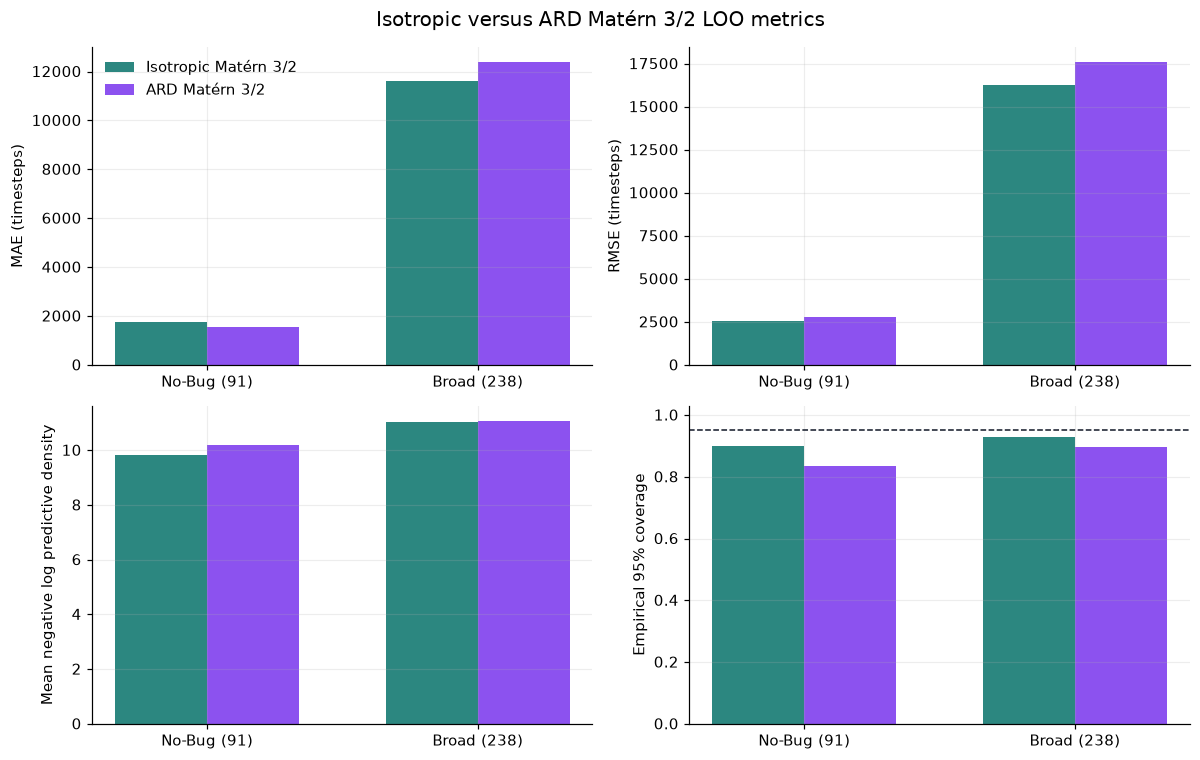

In [14]:
# Figure 1: metric comparison (exactly one saved PNG).
figure, axes = plt.subplots(2, 2, figsize=(11, 7))
metric_panels = [
    ("MAE", "MAE (timesteps)", False),
    ("RMSE", "RMSE (timesteps)", False),
    (
        "mean_negative_log_predictive_density",
        "Mean negative log predictive density",
        False,
    ),
    ("empirical_95_interval_coverage", "Empirical 95% coverage", True),
]
x = np.arange(2)
width = 0.34
for axis, (column, label, show_target) in zip(axes.flat, metric_panels):
    for offset, kernel_key in [(-width / 2, ISO_KEY), (width / 2, ARD_KEY)]:
        values = [
            metrics.loc[
                metrics["dataset"].eq(dataset)
                & metrics["kernel_key"].eq(kernel_key),
                column,
            ].iloc[0]
            for dataset in ["clean", "broad"]
        ]
        axis.bar(
            x + offset,
            values,
            width,
            label=KERNEL_LABELS[kernel_key],
            color=COLORS[kernel_key],
            alpha=0.88,
        )
    if show_target:
        axis.axhline(0.95, color="#111827", linestyle="--", linewidth=1)
        axis.set_ylim(0, 1.03)
    axis.set_xticks(x, ["No-Bug (91)", "Broad (238)"])
    axis.set_ylabel(label)
axes[0, 0].legend(frameon=False)
figure.suptitle("Isotropic versus ARD Matérn 3/2 LOO metrics", fontsize=13)
figure.tight_layout()
figure.savefig(
    OUTPUT_ROOT / "matern32_metric_comparison.png",
    bbox_inches="tight",
)
plt.show()

C:\Users\ozgur\AppData\Local\Temp\ipykernel_19628\2589419101.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(
C:\Users\ozgur\AppData\Local\Temp\ipykernel_19628\2589419101.py:9: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  axis.boxplot(


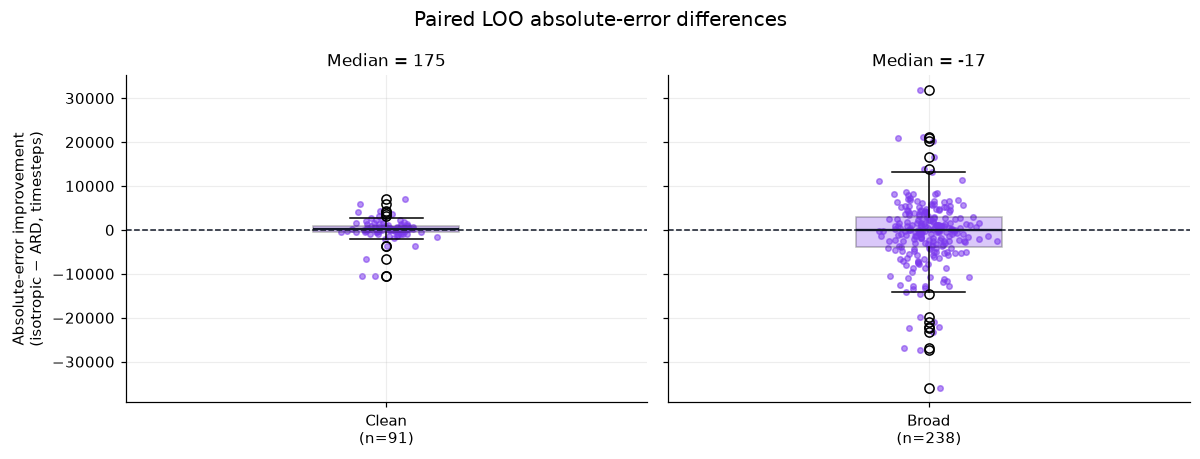

In [15]:
# Figure 2: paired absolute-error differences; positive values favour ARD.
figure, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for axis, dataset in zip(axes, ["clean", "broad"]):
    values = paired_errors.loc[
        paired_errors["dataset"].eq(dataset),
        "paired_absolute_error_improvement_isotropic_minus_ard",
    ].to_numpy(float)
    rng = np.random.default_rng(42)
    axis.boxplot(
        values,
        vert=True,
        widths=0.28,
        patch_artist=True,
        boxprops={"facecolor": COLORS[ARD_KEY], "alpha": 0.28},
        medianprops={"color": "#111827", "linewidth": 1.5},
    )
    axis.scatter(
        1 + rng.normal(0, 0.045, size=len(values)),
        values,
        s=13,
        alpha=0.55,
        color=COLORS[ARD_KEY],
    )
    axis.axhline(0, color="#111827", linestyle="--", linewidth=1)
    axis.set_xticks([1], [f"{dataset.title()}\n(n={len(values)})"])
    axis.set_title(f"Median = {np.median(values):.0f}")
axes[0].set_ylabel("Absolute-error improvement\n(isotropic − ARD, timesteps)")
figure.suptitle("Paired LOO absolute-error differences", fontsize=13)
figure.tight_layout()
figure.savefig(
    OUTPUT_ROOT / "matern32_paired_absolute_error_differences.png",
    bbox_inches="tight",
)
plt.show()

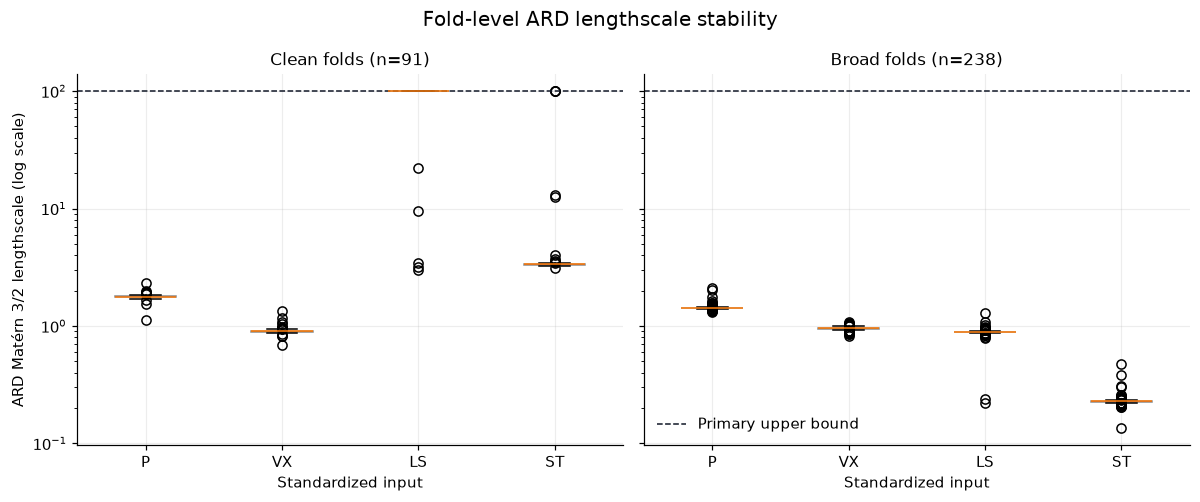

In [16]:
# Figure 3: fold-level ARD lengthscale distributions.
figure, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)
for axis, dataset in zip(axes, ["clean", "broad"]):
    subset = fold_hyperparameters.loc[
        fold_hyperparameters["dataset"].eq(dataset)
    ]
    data = [
        subset[f"ard_lengthscale_{input_name}"].to_numpy(float)
        for input_name in INPUT_COLUMNS
    ]
    boxes = axis.boxplot(data, tick_labels=INPUT_COLUMNS, patch_artist=True)
    for patch, color in zip(
        boxes["boxes"], ["#2563EB", "#D97706", "#059669", "#DC2626"]
    ):
        patch.set_facecolor(color)
        patch.set_alpha(0.45)
    axis.axhline(
        PRIMARY_LENGTH_BOUNDS[1],
        color="#111827",
        linestyle="--",
        linewidth=1,
        label="Primary upper bound",
    )
    axis.set_yscale("log")
    axis.set_title(f"{dataset.title()} folds (n={len(subset)})")
    axis.set_xlabel("Standardized input")
axes[0].set_ylabel("ARD Matérn 3/2 lengthscale (log scale)")
axes[1].legend(frameon=False, loc="lower left")
figure.suptitle("Fold-level ARD lengthscale stability", fontsize=13)
figure.tight_layout()
figure.savefig(
    OUTPUT_ROOT / "ard_matern32_fold_lengthscale_distributions.png",
    bbox_inches="tight",
)
plt.show()

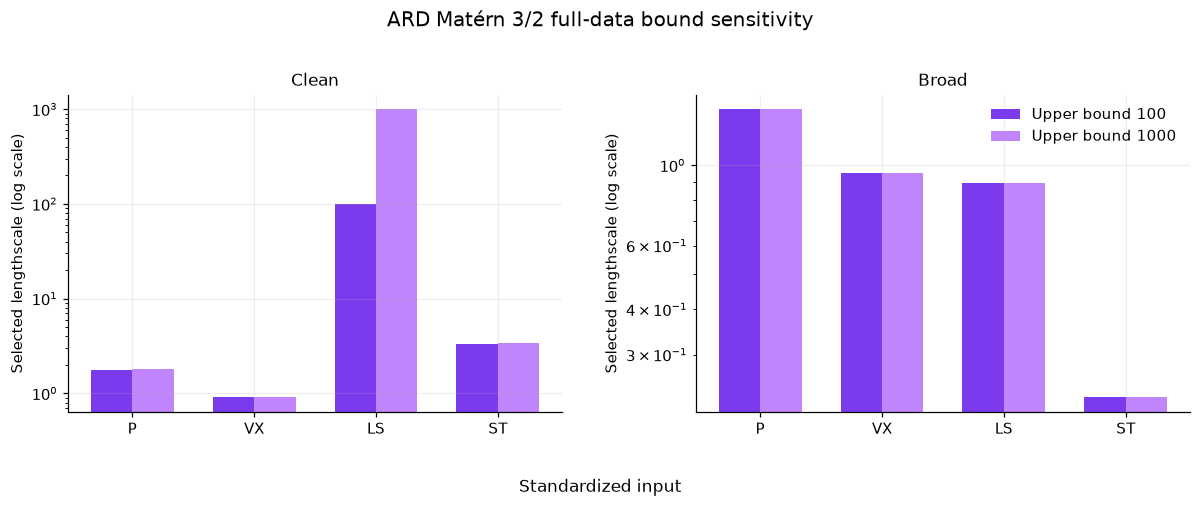

In [17]:
# Figure 4: selected full-data primary versus widened-bound lengthscales.
figure, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=False)
x = np.arange(len(INPUT_COLUMNS))
width = 0.34
for axis, dataset in zip(axes, ["clean", "broad"]):
    selected = selected_sensitivity.loc[
        selected_sensitivity["dataset"].eq(dataset)
    ].set_index("bound_setting")
    for offset, setting, label, color in [
        (-width / 2, "primary_upper_1e2", "Upper bound 100", "#7C3AED"),
        (width / 2, "widened_upper_1e3", "Upper bound 1000", "#C084FC"),
    ]:
        values = [
            selected.loc[setting, f"ard_lengthscale_{input_name}"]
            for input_name in INPUT_COLUMNS
        ]
        axis.bar(x + offset, values, width, label=label, color=color)
    axis.set_xticks(x, INPUT_COLUMNS)
    axis.set_yscale("log")
    axis.set_title(dataset.title())
    axis.set_ylabel("Selected lengthscale (log scale)")
axes[1].legend(frameon=False)
figure.suptitle("ARD Matérn 3/2 full-data bound sensitivity", fontsize=13)
figure.supxlabel("Standardized input", y=0.02)
figure.tight_layout(rect=[0, 0.04, 1, 0.96], w_pad=3.0)
figure.savefig(
    OUTPUT_ROOT / "ard_matern32_full_data_lengthscales.png",
    bbox_inches="tight",
)
plt.show()

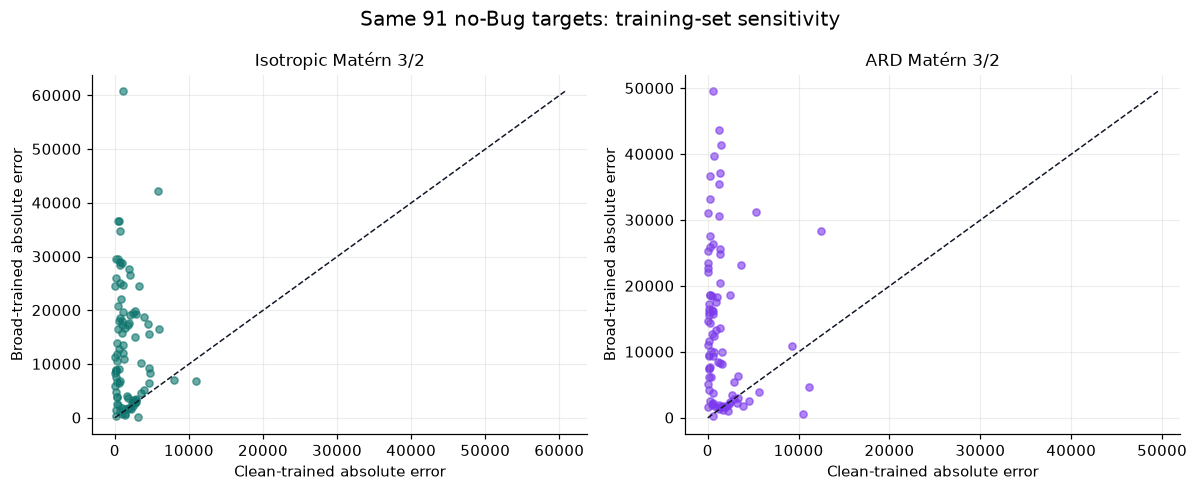

In [18]:
# Figure 5: same no-Bug point errors for isotropic and ARD Matérn 3/2.
prior_same_comparison = pd.read_csv(
    PHASE2_ROOT / "same_clean_points/same_clean_points_comparison.csv"
)
prior_iso_points = prior_same_comparison.loc[
    prior_same_comparison["kernel_key"].eq(ISO_KEY)
].copy()
if len(prior_iso_points) != EXPECTED_CLEAN:
    raise RuntimeError("Prior isotropic same-clean point table missing rows.")
figure, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for axis, label, frame in [
    (axes[0], "Isotropic Matérn 3/2", prior_iso_points),
    (axes[1], "ARD Matérn 3/2", same_clean),
]:
    maximum = float(
        max(
            frame["clean_trained_absolute_error"].max(),
            frame["broad_trained_absolute_error"].max(),
        )
    )
    axis.scatter(
        frame["clean_trained_absolute_error"],
        frame["broad_trained_absolute_error"],
        s=22,
        alpha=0.62,
        color=COLORS[ARD_KEY] if "ARD" in label else COLORS[ISO_KEY],
    )
    axis.plot([0, maximum], [0, maximum], "--", color="#111827", linewidth=1)
    axis.set_title(label)
    axis.set_xlabel("Clean-trained absolute error")
    axis.set_ylabel("Broad-trained absolute error")
figure.suptitle("Same 91 no-Bug targets: training-set sensitivity", fontsize=13)
figure.tight_layout()
figure.savefig(
    OUTPUT_ROOT / "ard_matern32_same_clean_points_errors.png",
    bbox_inches="tight",
)
plt.show()

**Figure interpretation.** Metric panels compare aggregate performance within
each dataset; paired plots show whether gains are widespread or driven by a
few cases. Lengthscale figures diagnose fold stability and upper-bound
dependence. The same-point plot isolates the training-data effect by
evaluating both training policies on identical no-Bug targets. None of
these plots establishes an exact physical transition time or causal
variable importance.

## 10. Structured summary and validation

In [19]:
validation_rows = []


def record_check(check: str, passed: bool, detail: str) -> None:
    validation_rows.append(
        {"check": check, "status": "PASS" if passed else "FAIL", "detail": detail}
    )


record_check(
    "expected dataset counts",
    (len(clean_data), len(broad_data), len(never_conduction)) == (91, 238, 3),
    f"clean={len(clean_data)}, broad={len(broad_data)}, never={len(never_conduction)}",
)
record_check(
    "raw target reconciliation",
    target_reconciliation["difference"].eq(0).all(),
    "mismatches=0",
)
record_check(
    "raw CSV SHA-256 unchanged",
    hashlib.sha256(RAW_CSV_PATH.read_bytes()).hexdigest() == raw_sha256_before,
    raw_sha256_before,
)
record_check(
    "isotropic Phase 2 reuse",
    len(clean_isotropic) == 91 and len(broad_isotropic) == 238,
    "settings, membership, targets, fold order, and scaler moments verified",
)
all_ard = pd.concat([clean_ard, broad_ard], ignore_index=True)
record_check(
    "ARD prediction accounting",
    len(all_ard) == 329
    and not all_ard.duplicated(["dataset", GROUP_COLUMN, "kernel_key"]).any(),
    f"rows={len(all_ard)}, duplicates={all_ard.duplicated(['dataset', GROUP_COLUMN, 'kernel_key']).sum()}",
)
record_check(
    "finite positive predictive standard deviations",
    np.isfinite(all_ard["predicted_std"]).all()
    and all_ard["predicted_std"].gt(0).all(),
    f"minimum={all_ard['predicted_std'].min():.6g}",
)
record_check(
    "experiment-level scaler isolation",
    not all_ard["heldout_in_scaler_fit"].any()
    and all_ard.groupby("dataset")["scaler_fit_rows"].nunique().eq(1).all()
    and all_ard.loc[all_ard["dataset"].eq("clean"), "scaler_fit_rows"].eq(90).all()
    and all_ard.loc[all_ard["dataset"].eq("broad"), "scaler_fit_rows"].eq(237).all(),
    "clean scaler rows=90; broad scaler rows=237; held-out rows excluded",
)
record_check(
    "matching ARD optimization settings",
    all_ard["alpha_jitter"].eq(ALPHA_JITTER).all()
    and all_ard["optimizer"].eq(OPTIMIZER).all()
    and all_ard["extra_optimizer_restarts"].eq(EXTRA_OPTIMIZER_RESTARTS).all()
    and all_ard["random_seed"].eq(RANDOM_SEED).all(),
    "alpha=1e-6, L-BFGS-B, one extra restart, seed=20260721",
)
record_check(
    "four ARD lengthscales per fold",
    all(
        all_ard[f"ard_lengthscale_{input_name}"].notna().all()
        for input_name in INPUT_COLUMNS
    ),
    "P, VX, LS, ST all present for 329 folds",
)
record_check(
    "no optimization fallback",
    not all_ard["fit_failed"].any() and not all_ard["fallback_used"].any(),
    f"failures={all_ard['fit_failed'].sum()}, fallbacks={all_ard['fallback_used'].sum()}",
)
record_check(
    "metric table accounting",
    len(metrics) == 4
    and set(metrics["dataset"]) == {"clean", "broad"}
    and set(metrics["kernel_key"]) == {ISO_KEY, ARD_KEY},
    f"rows={len(metrics)}",
)
record_check(
    "paired error accounting",
    len(paired_errors) == 329
    and not paired_errors.duplicated(["dataset", GROUP_COLUMN]).any(),
    f"rows={len(paired_errors)}",
)
record_check(
    "paired bootstrap specification",
    len(bootstrap_summary) == 4
    and bootstrap_summary["bootstrap_resamples"].eq(BOOTSTRAP_RESAMPLES).all(),
    f"rows={len(bootstrap_summary)}, resamples={BOOTSTRAP_RESAMPLES}",
)
record_check(
    "same no-Bug point accounting",
    len(same_clean) == 91 and same_clean[GROUP_COLUMN].is_unique,
    f"rows={len(same_clean)}",
)
record_check(
    "fold hyperparameter accounting",
    len(fold_hyperparameters) == 329
    and len(lengthscale_summary) == 8,
    f"fold rows={len(fold_hyperparameters)}, summary rows={len(lengthscale_summary)}",
)
record_check(
    "full-data fit accounting",
    len(full_data_fits) == 4,
    "two kernels × two datasets",
)
record_check(
    "bound sensitivity matched starts",
    len(bound_sensitivity) == 20
    and bound_sensitivity.groupby(["dataset", "bound_setting"]).size().eq(5).all()
    and selected_sensitivity.groupby(["dataset", "bound_setting"]).size().eq(1).all(),
    f"fits={len(bound_sensitivity)}, selected={len(selected_sensitivity)}",
)
expected_pngs = {
    "matern32_metric_comparison.png",
    "matern32_paired_absolute_error_differences.png",
    "ard_matern32_fold_lengthscale_distributions.png",
    "ard_matern32_full_data_lengthscales.png",
    "ard_matern32_same_clean_points_errors.png",
}
actual_pngs = {path.name for path in OUTPUT_ROOT.glob("*.png")}
record_check(
    "exactly five requested PNG figures",
    actual_pngs == expected_pngs,
    f"files={sorted(actual_pngs)}",
)
record_check(
    "Phase 1 audit remains available",
    AUDIT_PATH.exists(),
    str(AUDIT_PATH.relative_to(ROOT)),
)

validation_results = pd.DataFrame(validation_rows)
validation_results.to_csv(
    OUTPUT_ROOT / "ard_matern32_validation_results.csv", index=False
)
if not validation_results["status"].eq("PASS").all():
    display(validation_results)
    raise RuntimeError("One or more notebook validation checks failed.")
display(validation_results)

,check,status,detail
0,expected dataset counts,PASS,"clean=91, broad=238, never=3"
1,raw target reconciliation,PASS,mismatches=0
2,raw CSV SHA-256 unchanged,PASS,964a12d86435e9f0879e2e43384d997e1cc2faa7b9e4c3aeb49cf0e73e3fb154
3,isotropic Phase 2 reuse,PASS,"settings, membership, targets, fold order, and scaler moments verified"
4,ARD prediction accounting,PASS,"rows=329, duplicates=0"
5,finite positive predictive standard deviations,PASS,minimum=623.126
6,experiment-level scaler isolation,PASS,clean scaler rows=90; broad scaler rows=237; held-out rows excluded
7,matching ARD optimization settings,PASS,"alpha=1e-6, L-BFGS-B, one extra restart, seed=20260721"
8,four ARD lengthscales per fold,PASS,"P, VX, LS, ST all present for 329 folds"
9,no optimization fallback,PASS,"failures=0, fallbacks=0"


In [20]:
def records_without_nan(frame: pd.DataFrame) -> list[dict]:
    return json.loads(frame.to_json(orient="records"))


clean_ard_metric = clean_metric.loc[ARD_KEY]
broad_ard_metric = broad_metric.loc[ARD_KEY]
clean_boot_rmse = bootstrap_summary.loc[
    bootstrap_summary["dataset"].eq("clean")
    & bootstrap_summary["metric_difference"].eq("RMSE_isotropic_minus_ARD")
].iloc[0]
broad_boot_rmse = bootstrap_summary.loc[
    bootstrap_summary["dataset"].eq("broad")
    & bootstrap_summary["metric_difference"].eq("RMSE_isotropic_minus_ARD")
].iloc[0]
clean_ard_better = clean_ard_metric["RMSE"] < clean_metric.loc[ISO_KEY, "RMSE"]
broad_ard_better = broad_ard_metric["RMSE"] < broad_metric.loc[ISO_KEY, "RMSE"]
broad_training_helps = (
    same_row["broad_trained_RMSE"] < same_row["clean_trained_RMSE"]
)

summary = {
    "experiment": "Week 5 ARD Matérn 3/2 robustness extension",
    "scientific_scope": {
        "inputs": INPUT_COLUMNS,
        "target": TARGET_COLUMN,
        "target_units": "raw simulation timestep number",
        "group": GROUP_COLUMN,
        "clean_simulations": len(clean_data),
        "broad_simulations": len(broad_data),
        "excluded_never_conduction": len(never_conduction),
    },
    "configuration": {
        "alpha_jitter": ALPHA_JITTER,
        "optimizer": OPTIMIZER,
        "extra_optimizer_restarts": EXTRA_OPTIMIZER_RESTARTS,
        "normalize_y": NORMALIZE_Y,
        "constant_bounds": list(CONSTANT_BOUNDS),
        "primary_lengthscale_bounds": list(PRIMARY_LENGTH_BOUNDS),
        "widened_lengthscale_bounds": list(WIDENED_LENGTH_BOUNDS),
        "random_seed": RANDOM_SEED,
        "bootstrap_resamples": BOOTSTRAP_RESAMPLES,
        "bootstrap_seed": BOOTSTRAP_SEED,
    },
    "metrics": records_without_nan(metrics),
    "paired_bootstrap": records_without_nan(bootstrap_summary),
    "same_clean_points": records_without_nan(same_clean_metrics),
    "lengthscale_summary": records_without_nan(lengthscale_summary),
    "full_data_fits": records_without_nan(full_data_fits),
    "selected_bound_sensitivity": records_without_nan(selected_sensitivity),
    "validation": records_without_nan(validation_results),
    "conclusions": {
        "ARD_improves_clean_RMSE": bool(clean_ard_better),
        "ARD_improves_broad_RMSE": bool(broad_ard_better),
        "broad_training_improves_same_clean_RMSE": bool(broad_training_helps),
        "ARD_lengthscales_are_causal_importance": False,
        "active_learning_started": False,
        "level_set_estimation_started": False,
    },
}
with (OUTPUT_ROOT / "ard_matern32_summary.json").open(
    "w", encoding="utf-8"
) as handle:
    json.dump(summary, handle, indent=2, ensure_ascii=False, allow_nan=False)

clean_lengths = full_ard.loc[full_ard["dataset"].eq("clean")].iloc[0]
broad_lengths = full_ard.loc[full_ard["dataset"].eq("broad")].iloc[0]
summary_markdown = f'''# Week 5.05 — ARD Matérn 3/2 results summary

## Scope

This targeted extension compares the existing isotropic Matérn 3/2 GP with
an ARD Matérn 3/2 GP under the identical experiment-level LOO protocol.
The operational no-Bug dataset contains 91 simulations and the broad
dataset contains 238; three never-Conduction simulations remain excluded.

## Main LOO results

| Dataset | Kernel | MAE | RMSE | R² | Mean NLPD | 95% coverage |
|---|---|---:|---:|---:|---:|---:|
| Clean | Isotropic Matérn 3/2 | {clean_metric.loc[ISO_KEY, "MAE"]:.3f} | {clean_metric.loc[ISO_KEY, "RMSE"]:.3f} | {clean_metric.loc[ISO_KEY, "R2"]:.4f} | {clean_metric.loc[ISO_KEY, "mean_negative_log_predictive_density"]:.4f} | {clean_metric.loc[ISO_KEY, "empirical_95_interval_coverage"]:.3f} |
| Clean | ARD Matérn 3/2 | {clean_ard_metric["MAE"]:.3f} | {clean_ard_metric["RMSE"]:.3f} | {clean_ard_metric["R2"]:.4f} | {clean_ard_metric["mean_negative_log_predictive_density"]:.4f} | {clean_ard_metric["empirical_95_interval_coverage"]:.3f} |
| Broad | Isotropic Matérn 3/2 | {broad_metric.loc[ISO_KEY, "MAE"]:.3f} | {broad_metric.loc[ISO_KEY, "RMSE"]:.3f} | {broad_metric.loc[ISO_KEY, "R2"]:.4f} | {broad_metric.loc[ISO_KEY, "mean_negative_log_predictive_density"]:.4f} | {broad_metric.loc[ISO_KEY, "empirical_95_interval_coverage"]:.3f} |
| Broad | ARD Matérn 3/2 | {broad_ard_metric["MAE"]:.3f} | {broad_ard_metric["RMSE"]:.3f} | {broad_ard_metric["R2"]:.4f} | {broad_ard_metric["mean_negative_log_predictive_density"]:.4f} | {broad_ard_metric["empirical_95_interval_coverage"]:.3f} |

Clean paired bootstrap RMSE difference (isotropic − ARD) is
{clean_boot_rmse["point_estimate"]:.3f}, with 95% percentile interval
[{clean_boot_rmse["bootstrap_95_CI_lower"]:.3f},
{clean_boot_rmse["bootstrap_95_CI_upper"]:.3f}]. Broad difference is
{broad_boot_rmse["point_estimate"]:.3f}, with interval
[{broad_boot_rmse["bootstrap_95_CI_lower"]:.3f},
{broad_boot_rmse["bootstrap_95_CI_upper"]:.3f}]. Positive values favour ARD.

## Same 91 no-Bug targets

ARD clean-trained RMSE is {same_row["clean_trained_RMSE"]:.3f}; ARD
broad-trained RMSE on the identical targets is
{same_row["broad_trained_RMSE"]:.3f}. Broad training improves
{int(same_row["clean_points_improved_by_broad_training"])} points and
worsens {int(same_row["clean_points_worsened_by_broad_training"])}.
The median paired improvement (clean minus broad absolute error) is
{same_row["median_paired_improvement_clean_minus_broad"]:.3f}.

## Full-data ARD diagnostics

Clean optimized kernel: `{clean_lengths["optimized_kernel_expression"]}`.

Broad optimized kernel: `{broad_lengths["optimized_kernel_expression"]}`.

Bound-sensitivity results are reported for all five deterministic starts
under upper bounds 100 and 1000. A lengthscale moving beyond 100 under the
widened bound is interpreted as weak identification of an almost-flat
direction, not as a precisely estimated large value.

## Scientific interpretation

ARD improves clean RMSE: **{clean_ard_better}**. ARD improves broad RMSE:
**{broad_ard_better}**. Broad training improves ARD RMSE on the same clean
targets: **{broad_training_helps}**.

These results assess predictive robustness under the fixed first-observed
target. They do not prove exact physical transition times, label correctness,
or causal input importance. Active learning and level-set estimation remain
not started.
'''
summary_markdown = "\n".join(
    line[4:] if line.startswith("    ") else line
    for line in summary_markdown.splitlines()
).strip() + "\n"
(OUTPUT_ROOT / "week5_05_results_summary.md").write_text(
    summary_markdown, encoding="utf-8"
)
display(Markdown(summary_markdown))

# Week 5.05 — ARD Matérn 3/2 results summary

## Scope

This targeted extension compares the existing isotropic Matérn 3/2 GP with
an ARD Matérn 3/2 GP under the identical experiment-level LOO protocol.
The operational no-Bug dataset contains 91 simulations and the broad
dataset contains 238; three never-Conduction simulations remain excluded.

## Main LOO results

| Dataset | Kernel | MAE | RMSE | R² | Mean NLPD | 95% coverage |
|---|---|---:|---:|---:|---:|---:|
| Clean | Isotropic Matérn 3/2 | 1735.765 | 2537.007 | 0.9171 | 9.8156 | 0.901 |
| Clean | ARD Matérn 3/2 | 1559.990 | 2808.296 | 0.8984 | 10.1858 | 0.835 |
| Broad | Isotropic Matérn 3/2 | 11616.871 | 16256.262 | 0.4060 | 11.0404 | 0.929 |
| Broad | ARD Matérn 3/2 | 12391.368 | 17596.191 | 0.3040 | 11.0712 | 0.895 |

Clean paired bootstrap RMSE difference (isotropic − ARD) is
-271.289, with 95% percentile interval
[-1203.379,
617.801]. Broad difference is
-1339.929, with interval
[-2763.252,
101.824]. Positive values favour ARD.

## Same 91 no-Bug targets

ARD clean-trained RMSE is 2808.296; ARD
broad-trained RMSE on the identical targets is
18051.785. Broad training improves
15 points and
worsens 76.
The median paired improvement (clean minus broad absolute error) is
-9415.964.

## Full-data ARD diagnostics

Clean optimized kernel: `1.05**2 * Matern(length_scale=[1.78, 0.905, 100, 3.36], nu=1.5)`.

Broad optimized kernel: `1.07**2 * Matern(length_scale=[1.43, 0.955, 0.893, 0.229], nu=1.5)`.

Bound-sensitivity results are reported for all five deterministic starts
under upper bounds 100 and 1000. A lengthscale moving beyond 100 under the
widened bound is interpreted as weak identification of an almost-flat
direction, not as a precisely estimated large value.

## Scientific interpretation

ARD improves clean RMSE: **False**. ARD improves broad RMSE:
**False**. Broad training improves ARD RMSE on the same clean
targets: **False**.

These results assess predictive robustness under the fixed first-observed
target. They do not prove exact physical transition times, label correctness,
or causal input importance. Active learning and level-set estimation remain
not started.


## 11. Notebook conclusion

In [21]:
clean_ls_medians = (
    lengthscale_summary.loc[lengthscale_summary["dataset"].eq("clean")]
    .set_index("input")["median"]
    .to_dict()
)
broad_ls_medians = (
    lengthscale_summary.loc[lengthscale_summary["dataset"].eq("broad")]
    .set_index("input")["median"]
    .to_dict()
)
display(
    Markdown(
        f'''
        ### What we learned

        ARD Matérn 3/2 achieved clean/broad RMSE values of
        **{clean_ard_metric["RMSE"]:.1f}** and
        **{broad_ard_metric["RMSE"]:.1f}** timesteps, compared with
        **{clean_metric.loc[ISO_KEY, "RMSE"]:.1f}** and
        **{broad_metric.loc[ISO_KEY, "RMSE"]:.1f}** for isotropic Matérn
        3/2. Clean fold-median ARD lengthscales are
        `P={clean_ls_medians["P"]:.3g}`,
        `VX={clean_ls_medians["VX"]:.3g}`,
        `LS={clean_ls_medians["LS"]:.3g}`,
        `ST={clean_ls_medians["ST"]:.3g}`; broad medians are
        `P={broad_ls_medians["P"]:.3g}`,
        `VX={broad_ls_medians["VX"]:.3g}`,
        `LS={broad_ls_medians["LS"]:.3g}`,
        `ST={broad_ls_medians["ST"]:.3g}`.

        ### What this means for the thesis

        The experiment directly tests whether anisotropic Matérn geometry
        is a robust extension of the Week 5 regression baseline. The clean
        and broad conclusions remain separate, and the paired bootstrap
        gives an uncertainty range for their performance differences.
        Bound hits are reported transparently rather than treated as exact
        feature-importance estimates.

        ### What remains unresolved

        - first observed Conduction may not be the exact physical transition;
        - broad targets can follow Screenshot Bug frames;
        - the current four inputs may omit design or batch structure;
        - ARD lengthscales describe fitted smoothness, not causal importance;
        - no active-learning or level-set decision is made here.

        ### Ioan requirement status

        - real dataset: **complete**
        - experiment-level target: **complete**
        - clean/no-Bug GP comparison: **complete**
        - broad GP comparison: **complete**
        - isotropic Matérn 3/2: **complete**
        - ARD Matérn 3/2: **complete**
        - matched hyperparameter optimization: **complete**
        - experiment-level LOO: **complete**
        - paired bootstrap robustness: **complete**
        - bound-sensitivity diagnostic: **complete**
        - optimizer-family comparison: **complete in Notebook 04; not expanded here**
        - active learning / level-set estimation: **not started**
        '''
    )
)


        ### What we learned

        ARD Matérn 3/2 achieved clean/broad RMSE values of
        **2808.3** and
        **17596.2** timesteps, compared with
        **2537.0** and
        **16256.3** for isotropic Matérn
        3/2. Clean fold-median ARD lengthscales are
        `P=1.77`,
        `VX=0.901`,
        `LS=100`,
        `ST=3.34`; broad medians are
        `P=1.43`,
        `VX=0.954`,
        `LS=0.893`,
        `ST=0.228`.

        ### What this means for the thesis

        The experiment directly tests whether anisotropic Matérn geometry
        is a robust extension of the Week 5 regression baseline. The clean
        and broad conclusions remain separate, and the paired bootstrap
        gives an uncertainty range for their performance differences.
        Bound hits are reported transparently rather than treated as exact
        feature-importance estimates.

        ### What remains unresolved

        - first observed Conduction may not be the exact physical transition;
        - broad targets can follow Screenshot Bug frames;
        - the current four inputs may omit design or batch structure;
        - ARD lengthscales describe fitted smoothness, not causal importance;
        - no active-learning or level-set decision is made here.

        ### Ioan requirement status

        - real dataset: **complete**
        - experiment-level target: **complete**
        - clean/no-Bug GP comparison: **complete**
        - broad GP comparison: **complete**
        - isotropic Matérn 3/2: **complete**
        - ARD Matérn 3/2: **complete**
        - matched hyperparameter optimization: **complete**
        - experiment-level LOO: **complete**
        - paired bootstrap robustness: **complete**
        - bound-sensitivity diagnostic: **complete**
        - optimizer-family comparison: **complete in Notebook 04; not expanded here**
        - active learning / level-set estimation: **not started**
        